In [84]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ipywidgets as widgets


In [85]:
# 1. LOAD DATA
INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - Full Integrity Audit Printing.
    """
    
    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)
    
    # --- STEP 1: RANKED DEDUPLICATION ---
    # Sort by significance so if 3 rows exist, we keep the 2 best.
    df = df.sort_values(['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'], 
                         ascending=[True, True, True, False, False])
    # LIMIT: Keep maximum 2 matches per Gameweek per Player
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)
    
    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])
    
    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]
    
    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")

    # --- STEP 4: CORE FEATURES ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)
    
    df['Season_Phase'] = pd.cut(df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]).astype(float)
    
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        team_gw_totals = df.groupby([team_col, 'season', 'Gameweek'])['Total Points'].transform('sum')
        df['Team_Point_Share'] = (df.groupby('Player UUID')['Total Points'].shift(1) / team_gw_totals).replace([np.inf, -np.inf], 0).fillna(0)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 5: SEASON BASELINE BRIDGE ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby('Player UUID')['Season_Avg_Points'].shift(1)
    
    df = df.merge(season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']], 
                  on=['Player UUID', 'season'], how='left')
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    return df.dropna(subset=['Next_Opponent_Difficulty'])

# Run and Save
df_augmented = enrich_features_v2(df)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
display(df_augmented[['Player Name', 'season', 'Gameweek', 'Prev_Season_Avg_Points', 'Rolling_Avg_Minutes_5']].head())

--- Final Integrity Audit ---
Legitimate DGW Match Pairs (Time-Series): 2465
Suspicious GWs (>2 matches): 0 (TARGET: 0)
Max Minutes in a single row: 90
Enhanced dataset created: ../output/forecaster_pro/fpl_features_augmented.csv


,Player Name,season,Gameweek,Prev_Season_Avg_Points,Rolling_Avg_Minutes_5
1,Alex Nicolao Telles,2020-21,9,0.0,0.000000
2,Alex Nicolao Telles,2020-21,10,0.0,90.000000
3,Alex Nicolao Telles,2020-21,11,0.0,86.500000
4,Alex Nicolao Telles,2020-21,13,0.0,87.666667
5,Alex Nicolao Telles,2020-21,14,0.0,88.250000


In [86]:
#  [Cell: Final Data Scrub - Removing Verified Ghosts]

# List of players verified as inactive in the 2025-26 Premier League
verified_ghosts = ['Thiago', 'Mane', 'Bale', 'Sadio Mané']

# Filter out these specific names ONLY for the 2025-26 season rows
# We keep them for older seasons so the model can still learn from their history
initial_count = len(df_augmented)

df_augmented = df_augmented[~(
    (df_augmented['Web Name'].isin(verified_ghosts)) & 
    (df_augmented['season'] == '2025-26')
)].copy()

removed_count = initial_count - len(df_augmented)
print(f"Surgical Clean Complete: Removed {removed_count} ghost rows from 2025-26.")

Surgical Clean Complete: Removed 27 ghost rows from 2025-26.


## Prev_Season_Avg_Points

It calculates the average points a player earned over the entire previous season.

It maps that average forward to the current season.

Result: The model now knows if a player is "Class" (e.g., Salah averaging 7 points all year) vs. just being in "Form" for a few weeks. This makes GW1 and GW2 predictions much more stable.

In [87]:
# [Cell: Verification - Salah's Season Bridge]

# 1. Identify Salah's UUID
# (search for 'salah' in the Web Name to be safe)
salah_data = df_augmented[df_augmented['Web Name'].str.contains('Salah', case=False, na=False)]

if not salah_data.empty:
    s_uuid = salah_data['Player UUID'].iloc[0]
    
    # 2. Get the transition rows (End of 24/25 and Start of 25/26)
    # We sort to ensure chronological order
    salah_history = df_augmented[df_augmented['Player UUID'] == s_uuid].sort_values(['season', 'Gameweek'])
    
    # 3. Find the exact point where 2024-25 ends and 2025-26 begins
    transition_mask = (salah_history['season'] == '2025-26') & (salah_history['season'].shift(1) == '2024-25')
    
    if transition_mask.any():
        idx = salah_history[transition_mask].index[0]
        # Get 3 games before and 3 games after the summer break
        display_df = salah_history.loc[idx-3 : idx+2]
        
        print(f"--- Verification: Season Baseline Bridge (Mohamed Salah) ---")
        print("Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.")
        display(display_df[['Player Name', 'season', 'Gameweek', 'Total Points', 'Prev_Season_Avg_Points']])
    else:
        print("Could not find the 2024-25 to 2025-26 transition for Salah in this specific slice.")
else:
    print("Salah not found in the current df_augmented slice.")

--- Verification: Season Baseline Bridge (Mohamed Salah) ---
Note how 'Prev_Season_Avg_Points' appears only when the new season (2025-26) starts.


,Player Name,season,Gameweek,Total Points,Prev_Season_Avg_Points
2096,Mohamed Salah,2024-25,36,2,6.593750
2097,Mohamed Salah,2024-25,37,2,6.593750
2099,Mohamed Salah,2025-26,1,8,9.052632
2100,Mohamed Salah,2025-26,2,5,9.052632
2101,Mohamed Salah,2025-26,3,3,9.052632


In [88]:
#INVESTIGATION IN THE INPUT FILE 

# 1. Look at the suspicious GWs
dgws_investigation = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

print(f"Investigating {len(dgws_investigation)} rows from suspicious Gameweeks...")

# 2. Check the 180 minute rows specifically
high_min_rows = df[df['Minutes Played'] >= 180]

print(f"Found {len(high_min_rows)} rows in the RAW dataset with >= 180 minutes.")

if not high_min_rows.empty:
    print("\nSample of 180-minute rows (Raw Data):")
    display(high_min_rows[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(10))

if not dgws_investigation.empty:
    print("\nSample of 'Triple' Gameweek rows (After our current filter):")
    display(dgws_investigation[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played']].head(10))

Investigating 0 rows from suspicious Gameweeks...
Found 0 rows in the RAW dataset with >= 180 minutes.


In [89]:

# Filter for players who still have more than 2 entries in a single week
final_suspicious = df_augmented.groupby(['Player UUID', 'season', 'Gameweek']).filter(lambda x: len(x) > 2)

if not final_suspicious.empty:
    print(f"Found {final_suspicious['Player UUID'].nunique()} players across 176 suspicious GW instances.")
    # Display a few examples to see why they stayed
    display(final_suspicious[['Player Name', 'season', 'Gameweek', 'Opponent Difficulty', 'Minutes Played', 'Total Points']].head(15))
else:
    print("No suspicious rows found in the current df_augmented.")

No suspicious rows found in the current df_augmented.


In [90]:
# Check if "Doubles" are actually different matches
dgws_check = df_augmented.groupby(['Player UUID', 'season', 'Gameweek'])['Opponent Difficulty'].nunique()
fake_doubles = dgws_check[dgws_check > 2] # This shouldn't really happen
print(f"Number of suspicious GWs with >2 different difficulties: {len(fake_doubles)}")

Number of suspicious GWs with >2 different difficulties: 0


In [91]:
df_augmented

,Player UUID,Code,Player Name,Web Name,Player Team Name,season,Gameweek,Minutes Played,Goals Scored,Assists,...,Avg_ICT Index_L5,Avg_Threat_L5,Avg_Creativity_L5,Avg_Influence_L5,Rolling_Avg_Minutes_5,Next_Opponent_Difficulty,Next_Is_Home,Season_Phase,Team_Point_Share,Prev_Season_Avg_Points
1,0034ff22-4d5f-4cf0-bdf4-fa5251506366,568,Alex Nicolao Telles,Telles,Man Utd,2020-21,9,90,0,0,...,0.00,0.0,0.00,0.00,0.000000,2.0,False,1.0,0.000000,0.0
2,0034ff22-4d5f-4cf0-bdf4-fa5251506366,568,Alex Nicolao Telles,Telles,Man Utd,2020-21,10,83,0,0,...,0.40,1.0,1.10,1.88,90.000000,4.0,False,1.0,0.139535,0.0
3,0034ff22-4d5f-4cf0-bdf4-fa5251506366,568,Alex Nicolao Telles,Telles,Man Utd,2020-21,11,90,0,1,...,1.68,1.0,7.96,7.88,86.500000,2.0,False,2.0,0.018868,0.0
4,0034ff22-4d5f-4cf0-bdf4-fa5251506366,568,Alex Nicolao Telles,Telles,Man Utd,2020-21,13,90,0,0,...,2.82,1.0,14.22,13.08,87.666667,3.0,True,2.0,0.111111,0.0
5,0034ff22-4d5f-4cf0-bdf4-fa5251506366,568,Alex Nicolao Telles,Telles,Man Utd,2020-21,14,30,0,0,...,3.74,1.0,19.68,16.88,88.250000,2.0,True,2.0,0.014085,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63955,fffe8b78-21ad-425e-8012-c93ae569f044,732,Christantus Uche,Uche,Crystal Palace,2025-26,18,13,0,0,...,0.70,5.8,0.44,0.96,12.600000,2.0,True,2.0,0.153846,0.0
63956,fffe8b78-21ad-425e-8012-c93ae569f044,732,Christantus Uche,Uche,Crystal Palace,2025-26,19,8,0,0,...,0.80,7.4,0.32,0.92,15.000000,4.0,False,2.0,0.026316,0.0
63957,fffe8b78-21ad-425e-8012-c93ae569f044,732,Christantus Uche,Uche,Crystal Palace,2025-26,20,18,0,0,...,0.80,7.4,0.32,0.92,14.200000,3.0,True,3.0,0.035714,0.0
63958,fffe8b78-21ad-425e-8012-c93ae569f044,732,Christantus Uche,Uche,Crystal Palace,2025-26,23,5,0,0,...,0.38,3.4,0.24,0.52,13.000000,3.0,False,3.0,0.038462,0.0


In [92]:
# [Cell: Updated Top-Tier Identification - 4.5 Threshold]
# 1. Calculate seasonal averages
seasonal_avg = df_augmented.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
seasonal_avg.rename(columns={'Total Points': 'avg_season_pts'}, inplace=True)

# 2. Cleanup & Merge
if 'avg_season_pts' in df_augmented.columns:
    df_augmented = df_augmented.drop(columns=['avg_season_pts'])
df_augmented = df_augmented.merge(seasonal_avg, on=['Player UUID', 'season'], how='left')

# 3. Define the New Global Elite Mask (> 4.5 avg points per season)
elite_mask = df_augmented['avg_season_pts'] > 4.5

print(f"--- Top-Tier Identification Summary (Threshold: 4.5) ---")
print(f"Total Rows in Dataset: {len(df_augmented):,}")
print(f"Total Elite Rows: {elite_mask.sum():,}")
print(f"Percentage of Data considered 'Elite': {(elite_mask.sum()/len(df_augmented))*100:.2f}%")

# 4. Display Table for Verification (Keep this if you like the visual check)
print(f"\nSample of Top Tier Players (Avg > 4.5 pts):")
elite_list = df_augmented[elite_mask][['Player Name', 'season', 'avg_season_pts']].drop_duplicates()
elite_list = elite_list.sort_values(by=['season', 'avg_season_pts'], ascending=[False, False])
display(elite_list.head(15))

--- Top-Tier Identification Summary (Threshold: 4.5) ---
Total Rows in Dataset: 60,670
Total Elite Rows: 4,629
Percentage of Data considered 'Elite': 7.63%

Sample of Top Tier Players (Avg > 4.5 pts):


,Player Name,season,avg_season_pts
10230,Erling Haaland,2025-26,7.192308
24992,Gabriel dos Santos Magalhães,2025-26,6.863636
50442,Declan Rice,2025-26,6.148148
8973,Bruno Borges Fernandes,2025-26,6.041667
23329,Antoine Semenyo,2025-26,6.038462
38628,Tom Edozie,2025-26,6.000000
45421,Matt O'Riley,2025-26,6.000000
3864,Bruno Guimarães Rodriguez Moura,2025-26,5.954545
52978,Daniel Muñoz Mejía,2025-26,5.631579
5739,Bukayo Saka,2025-26,5.500000


## Cell 2: Augmented Window Generation (Context-Aware)

In [93]:
# [Cell 2: Augmented Window Generation - Including Season Baseline]

# 1. SETUP PROFESSIONAL FOLDER STRUCTURE
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def generate_fpl_windows_pro(df, window_size=6):
    train_data = []
    uuid_col = 'Player UUID'
    
    # Ensure chronological order for proper window sliding
    df = df.sort_values([uuid_col, 'season', 'Gameweek'])
    
    for pid, group in df.groupby(uuid_col):
        points = group['Total Points'].values
        
        # Pull features prepared in Cell 1
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        # NEW: The Long-term Class feature
        season_baseline = group['Prev_Season_Avg_Points'].values
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0] 
        
        for i in range(len(points) - window_size):
            # 1. THE PAST: The 6-week "Form" window
            window = points[i : i + window_size]
            
            # 2. THE FUTURE CONTEXT: Metadata for the target match
            target_idx = i + window_size - 1
            t_diff = next_diff[target_idx] 
            t_home = next_home[target_idx]
            t_min = avg_min[target_idx]
            t_phase = phase[target_idx]
            t_baseline = season_baseline[target_idx] # New input
            
            # 3. THE TARGET: Actual outcome
            target_points = points[i + window_size]
            
            # Skip "Ghost" windows (0 points everywhere)
            if np.all(window == 0) and target_points == 0:
                continue
                
            # Create the data row (Adding t_baseline)
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_baseline, target_points]
            train_data.append(row)
            
    # Professional Column Names
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
              ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'target']
              
    return pd.DataFrame(train_data, columns=columns)

# Execute the Pro window generation
windowed_df = generate_fpl_windows_pro(df_augmented)
windowed_df['position'] = windowed_df['position'].astype('category')

# Save features
WINDOWED_FEATURES_PATH = PRO_OUTPUT_DIR / 'fpl_windowed_features_pro.csv'
windowed_df.to_csv(WINDOWED_FEATURES_PATH, index=False)

print(f"Pro Windowed dataset created with Season Baseline: {WINDOWED_FEATURES_PATH}")
print(f"Total Training Windows: {windowed_df.shape[0]}")
display(windowed_df.head())

Pro Windowed dataset created with Season Baseline: ..\output\forecaster_pro\fpl_windowed_features_pro.csv
Total Training Windows: 53408


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,next_difficulty,next_is_home,rolling_min,season_phase,season_baseline,target
0,6,1,5,1,1,1,DEF,2.0,True,76.6,2.0,0.000000,7
1,1,5,1,1,1,7,DEF,4.0,False,67.6,3.0,0.000000,1
2,5,1,1,1,7,1,DEF,3.0,False,67.2,4.0,0.000000,1
3,1,1,1,7,1,1,DEF,4.0,False,67.2,2.0,2.777778,2
4,1,1,7,1,1,2,DEF,4.0,True,64.6,2.0,2.777778,1


## Cell 3: Data Splitting and Scaling (Comparison Setup)

In [94]:
# [Cell 3: Corrected Splitting (Recent 5 GW Window)]

# 1. SETUP PARAMETERS
CURRENT_SEASON = "2025-26"
CURRENT_GW = 29
VALIDATION_WINDOW = 5 

# 2. IDENTIFY VALIDATION INDEX
# We extract the season and GW info using the index of windowed_df
split_info = df_augmented.iloc[windowed_df.index][['season', 'Gameweek']]

# Create the mask
val_mask_series = (split_info['season'] == CURRENT_SEASON) & \
                  (split_info['Gameweek'] >= (CURRENT_GW - VALIDATION_WINDOW)) & \
                  (split_info['Gameweek'] < CURRENT_GW)

# FIX: Convert to values (numpy array) to avoid IndexingError
val_mask = val_mask_series.values

# 3. EXECUTE SPLIT
train_df = windowed_df[~val_mask].copy()
val_df = windowed_df[val_mask].copy()

X_train_raw = train_df.drop(columns=['target'])
y_train = train_df['target']

X_val_raw = val_df.drop(columns=['target'])
y_val = val_df['target']

# 4. NUMERIC FEATURES
numeric_cols = [
    c for c in X_train_raw.columns
    if 'lag' in c or 'difficulty' in c or 'min' in c or 'phase' in c
]

# 5. SCALING
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])

X_val_scaled = X_val_raw.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val_raw[numeric_cols])

# 6. SAVE SCALER
SCALER_PATH = PRO_OUTPUT_DIR / 'fpl_pro_scaler.pkl'
joblib.dump(scaler, SCALER_PATH)

print(f"--- Supervisor Split Logic Applied ---")
print(f"Validation Period: {CURRENT_SEASON} | Matches GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1}")
print(f"Training windows: {len(X_train_raw):,}")
print(f"Validation windows: {len(X_val_raw):,}")

--- Supervisor Split Logic Applied ---
Validation Period: 2025-26 | Matches GW 24 to 28
Training windows: 52,407
Validation windows: 1,001


## Cell 4: Parallel Training & Performance Comparison for scaled and unscaled model

In [95]:
# 1. SETUP PARAMETERS (Shared for both models)
lgbm_params = {
    'n_estimators': 1500,
    'learning_rate': 0.01,
    'max_depth': 7,
    'num_leaves': 40,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbosity': -1
}

# 2. TRAIN MODEL A: THE RAW VERSION
print(" Training RAW Model (No Scaling)...")
model_raw = lgb.LGBMRegressor(**lgbm_params)
model_raw.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 3. TRAIN MODEL B: THE SCALED VERSION
print("\n Training SCALED Model (StandardScaler)...")
model_scaled = lgb.LGBMRegressor(**lgbm_params)
model_scaled.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position', 'next_is_home'],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 4. PREDICTIONS & METRICS
preds_raw = model_raw.predict(X_val_raw)
preds_scaled = model_scaled.predict(X_val_scaled)

results_comparison = {
    'Metric': ['MAE', 'RMSE'],
    'Raw Model': [
        mean_absolute_error(y_val, preds_raw),
        np.sqrt(mean_squared_error(y_val, preds_raw))
    ],
    'Scaled Model': [
        mean_absolute_error(y_val, preds_scaled),
        np.sqrt(mean_squared_error(y_val, preds_scaled))
    ]
}

# 5. DISPLAY RESULTS
df_metrics = pd.DataFrame(results_comparison)
print("\n--- Final Performance Comparison ---")
display(df_metrics)

# 6. SAVE THE WINNER
# Usually, they will be very close, but save both for safety
model_raw.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_raw.txt'))
model_scaled.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_pro_model_scaled.txt'))

# In Cell 4, add this at the bottom:
mae_v1 = mean_absolute_error(y_val, preds_raw)

 Training RAW Model (No Scaling)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[645]	valid_0's l2: 8.2536

 Training SCALED Model (StandardScaler)...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[632]	valid_0's l2: 8.25974

--- Final Performance Comparison ---


,Metric,Raw Model,Scaled Model
0,MAE,2.101401,2.101736
1,RMSE,2.872909,2.873976


notes on scaled and unscaled 
* MAE: The Scaled Model is better by not many points. 
* RMSE: The Raw Model is actually slightly better here.

So, LightGBM does not care about scaling?  

## Cell 5: The "Top Performer" Error Analysis (calculating MAE specifically for the high-scorers)

Overall Validation MAE: 2.1014
MAE for Elite Players (>4.5 Season Avg): 2.1274


C:\Users\skourako\AppData\Local\Temp\ipykernel_16456\2794045655.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')


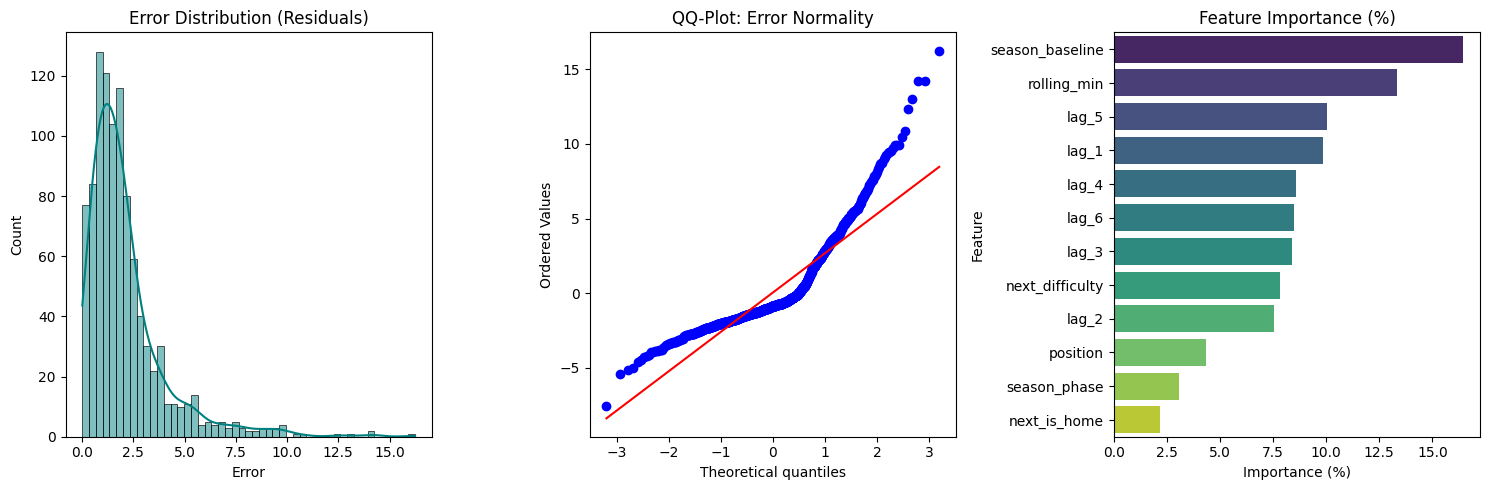

In [96]:
# [Cell 5: Error Analysis & Feature Importance - Fixed]

# 1. PREPARE ANALYSIS DATAFRAME
analysis_df = X_val_raw.copy()
analysis_df['Actual'] = y_val.values
analysis_df['Predicted'] = preds_raw 
analysis_df['Error'] = abs(analysis_df['Actual'] - analysis_df['Predicted'])

# NEW: Filter error analysis by the Elite Mask (>4.5 seasonal average)
# map the mask from df_augmented back to the validation slice
elite_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
elite_performers_audit = analysis_df.loc[analysis_df.index.isin(elite_indices)]

top_mae = elite_performers_audit['Error'].mean()

print(f"Overall Validation MAE: {df_metrics.iloc[0, 1]:.4f}")
print(f"MAE for Elite Players (>4.5 Season Avg): {top_mae:.4f}")

# 3. VISUALIZATION: Error Distribution & QQ-Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(analysis_df['Error'], kde=True, color='teal')
plt.title('Error Distribution (Residuals)')

plt.subplot(1, 3, 2)
stats.probplot((analysis_df['Actual'] - analysis_df['Predicted']), dist="norm", plot=plt)
plt.title('QQ-Plot: Error Normality')

# 4. FEATURE IMPORTANCE WITH PERCENTAGES
plt.subplot(1, 3, 3)
importances = model_raw.feature_importances_

# FIX: Use X_train_raw.columns instead of X.columns
feature_names = X_train_raw.columns 
rel_importances = 100 * (importances / importances.sum())

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance (%)': rel_importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance (%)', ascending=False)

sns.barplot(x='Importance (%)', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance (%)')

plt.tight_layout()
plt.show()

# 5. SAVE FEATURE IMPORTANCE LOG
feat_imp_df.to_csv(PRO_OUTPUT_DIR / 'fpl_pro_feature_importance.csv', index=False)

Notes 
MAE: 
* Overall MAE (2.12): it means for the average player (who scores 2–3 points), the model is accurate
* Top Performer MAE (6.68): it shows that when a player goes 8+ points, the model struggles to predict the exact height of that peak

Plots: 
* model has "thin tails" , it is conservative. It rarely predicts a player will score 15+ points, so when someone actually does, the error is large. The model prefers to stay safe near the average.

Feature Importance: 
* rolling_min is #1




## Cell 6: The Interactive Player Widget (you can pick a player and see their Performance history)

In [97]:
#%pip install ipywidgets

In [98]:
# [Cell 6: Seasonal Evaluation - Standard Professional Dropdown]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' 
    # This bypasses the dropna() from Cell 1 to ensure GW28 is displayed
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        return

    # 2. PREPARE EVALUATION (GW 24-28) + LIVE PREDICTION (GW 29)
    target_gws = list(range(24, 30)) 
    pred_rows = []
    
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw < 29:
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            lags = list(full_hist['Total Points'].tail(6).values)
            last = full_hist.iloc[-1]
            feat = lags + [
                last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']
            ]
            pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
    
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        # Change from model_v4 to model_raw (Baseline V1)
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
    else:
        pred_df = pd.DataFrame()

    # 3. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # HISTORICAL ACTUALS: Navy (#003f5c)
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # MODEL PREDICTIONS: Action Orange (#ff7c43)
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'], 
                 color='#ff7c43', label='Model Predictions (Eval + GW29)', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)
        
        # CONFIDENCE INTERVAL: Gold (#ffa60022)
        # Updated to use mae_v1 for accurate V1 error visualization
        mae_proxy = globals().get('mae_v1', 1.84)
        plt.fill_between([24, 29], 0, plt.gca().get_ylim()[1], color='orange', alpha=0.03)

    # Vertical split at GW 24
    plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    plt.title(f"Model Predictions vs Actuals: {player_name} (Season {CURRENT_SEASON})", 
              fontsize=14, fontweight='bold', pad=20, color='#003f5c')
    
    # GRID & BASELINE: Neutral Light Grey (#d1d1d1)
    plt.xticks(np.arange(1, 30, 1), color='#003f5c') 
    plt.xlim(0.5, 29.5)
    plt.ylabel("Points", fontsize=12, color='#003f5c')
    plt.xlabel("Gameweek", fontsize=12, color='#003f5c')
    plt.grid(True, axis='y', linestyle='-', color='#d1d1d1', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#d1d1d1')
    ax.spines['bottom'].set_color('#d1d1d1')
    
    plt.tight_layout()
    plt.show()

# 4. STRICT EVALUATION SET DROPDOWN (Season-Locked)
# This identifies unique UUIDs that exist in our validation split
eval_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()

# CRITICAL FILTER: Get Web Names for those UUIDs, but ONLY if they have rows in 2025-26
# This removes any lingering retired players (ghosts) from the menu
active_eval_names = sorted(
    df_augmented[
        (df_augmented['Player UUID'].isin(eval_uuids)) & 
        (df_augmented['season'] == CURRENT_SEASON)
    ]['Web Name'].unique()
)

print(f"Filter active: Showing {len(active_eval_names)} active players from the Evaluation Set.")

dropdown_menu = widgets.Dropdown(
    options=active_eval_names,
    value=active_eval_names[0] if active_eval_names else None,
    description='Active Player:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

widgets.interact(plot_professional_backtest, player_name=dropdown_menu)



Filter active: Showing 306 active players from the Evaluation Set.


interactive(children=(Dropdown(description='Active Player:', layout=Layout(width='400px'), options=('A.Becker'…

<function __main__.plot_professional_backtest(player_name)>

In [99]:
#[Cell 6: Seasonal Evaluation - Searchable Audit with Local MAE]
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

def plot_professional_backtest(player_name):
    # 1. GET ACTUALS FROM RAW 'df' (Ensures GW28 is displayed)
    season_actuals = df[
        (df['Web Name'] == player_name) & 
        (df['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')
    
    if season_actuals.empty:
        print(f"No actual data found for {player_name}.")
        return

    # 2. PREPARE PREDICTIONS (GW 24-29)
    target_gws = list(range(24, 30)) 
    pred_rows = []
    
    player_uuid = season_actuals['Player UUID'].iloc[0]
    full_hist = df_augmented[df_augmented['Player UUID'] == player_uuid].sort_values(['season', 'Gameweek'])
    
    for gw in target_gws:
        if gw < 29:
            row_match = full_hist[(full_hist['season'] == CURRENT_SEASON) & (full_hist['Gameweek'] == gw)]
            if not row_match.empty:
                idx = row_match.index[0]
                pos_in_hist = full_hist.index.get_loc(idx)
                if pos_in_hist >= 6:
                    lags = list(full_hist.iloc[pos_in_hist-6:pos_in_hist]['Total Points'].values)
                    feat = lags + [
                        row_match['Position'].iloc[0], row_match['Next_Opponent_Difficulty'].iloc[0],
                        row_match['Next_Is_Home'].iloc[0], row_match['Rolling_Avg_Minutes_5'].iloc[0],
                        row_match['Season_Phase'].iloc[0], row_match['Prev_Season_Avg_Points'].iloc[0]
                    ]
                    pred_rows.append({'Gameweek': gw, 'Features': feat})
        else:
            # GW 29 Live Prediction
            if not full_hist.empty:
                lags = list(full_hist['Total Points'].tail(6).values)
                last = full_hist.iloc[-1]
                feat = lags + [
                    last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'],
                    last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']
                ]
                pred_rows.append({'Gameweek': gw, 'Features': feat})

    # Generate Predictions
    v_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
             ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
    
    player_mae = None
    if pred_rows:
        inf_df = pd.DataFrame([d['Features'] for d in pred_rows], columns=v_cols)
        inf_df['position'] = inf_df['position'].astype('category')
        
        # Use Baseline (model_raw) for chronological consistency
        preds = model_raw.predict(inf_df)
        pred_df = pd.DataFrame({'Gameweek': [d['Gameweek'] for d in pred_rows], 'Predicted': preds})
        
        # 3. CALCULATE LOCAL MAE (For GW 24-28 only)
        eval_actuals = season_actuals[season_actuals['Gameweek'].isin(range(24, 29))]['Total Points']
        eval_preds = pred_df[pred_df['Gameweek'] < 29]['Predicted']
        
        if len(eval_actuals) == len(eval_preds) and len(eval_actuals) > 0:
            player_mae = mean_absolute_error(eval_actuals, eval_preds)
    else:
        pred_df = pd.DataFrame()

    # 4. PLOTTING
    plt.figure(figsize=(15, 6), facecolor='white')
    
    # ACTUALS: Solid Blue
    plt.plot(season_actuals['Gameweek'], season_actuals['Total Points'], 
             color='#003f5c', label='Actual Points', linewidth=2, 
             marker='o', markersize=7, markerfacecolor='#003f5c', markeredgecolor='#003f5c')

    # PREDICTIONS: Orange Dashed
    if not pred_df.empty:
        plt.plot(pred_df['Gameweek'], pred_df['Predicted'], 
                 color='#ff7f0e', label='V1 Baseline Predictions', 
                 linewidth=2.5, linestyle='--', marker='x', markersize=10, markeredgewidth=3)

    plt.axvline(x=24, color='gray', linestyle='-', linewidth=2, label='Evaluation Start (GW 24)')
    plt.axvline(x=24, color='#d1d1d1', linestyle='-', linewidth=2, alpha=0.8)

    # Dynamic Title with Player MAE
    title_str = f"Model Predictions vs Actuals: {player_name}"
    if player_mae is not None:
        title_str += f" | Player MAE (GW24-28): {player_mae:.2f}"
    
    plt.title(title_str, fontsize=14, fontweight='bold', pad=20)
    plt.xticks(np.arange(1, 30, 1)) 
    plt.xlim(0.5, 29.5)
    plt.ylabel("Points", fontsize=12)
    plt.xlabel("Gameweek", fontsize=12)
    plt.grid(True, axis='y', linestyle=':', alpha=0.5)
    plt.legend(frameon=True, loc='upper left')
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

# 5. SEARCHABLE EVALUATION SET COMBOBOX (Season-Locked)
# Identify UUIDs from the validation split
eval_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()

# Filter names to ensure they belong to the current active season ONLY
active_eval_names = sorted(
    df_augmented[
        (df_augmented['Player UUID'].isin(eval_uuids)) & 
        (df_augmented['season'] == CURRENT_SEASON)
    ]['Web Name'].unique()
)

print(f"Audit Search active: {len(active_eval_names)} active players available.")

# Combobox allows keyboard typing and suggestion filtering
search_box = widgets.Combobox(
    value=active_eval_names[0] if active_eval_names else '',
    placeholder='Type a player name...',
    options=active_eval_names,  # Restricted to active players
    description='Player:',
    ensure_option=True,         # Prevents errors from typing non-existent names
    interactive=True,
    layout=widgets.Layout(width='450px')
)

widgets.interact(plot_professional_backtest, player_name=search_box)

Audit Search active: 306 active players available.


interactive(children=(Combobox(value='A.Becker', description='Player:', ensure_option=True, layout=Layout(widt…

<function __main__.plot_professional_backtest(player_name)>

In [100]:
# [Cell: Validation Set Integrity Check]

# 1. Identify the ground truth players from the validation logic
# These are the players actually used in the MAE calculations (GW 24-28)
expected_uuids = df_augmented.loc[val_df.index, 'Player UUID'].unique()
expected_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 2. Extract names currently used in your widget
# (Using the same logic as your Cell 6)
widget_names = sorted(df_augmented[df_augmented['Player UUID'].isin(expected_uuids)]['Web Name'].unique())

# 3. Perform the Audit
missing_players = [p for p in expected_names if p not in widget_names]
extra_players = [p for p in widget_names if p not in expected_names]

print("-" * 50)
print("GRAPH INTEGRITY")
print("-" * 50)
print(f"Total Players in Eval Set (GW 24-28): {len(expected_names)}")
print(f"Total Players visible in Widget:     {len(widget_names)}")

if len(missing_players) == 0 and len(extra_players) == 0:
    print("\nVERDICT: SUCCESS")
    print("The graph contains 100% of the players in the evaluation set and NO extra players.")
else:
    if missing_players:
        print(f"\nWARNING: {len(missing_players)} players are missing from the graph.")
    if extra_players:
        print(f"\nWARNING: {len(extra_players)} players are appearing that shouldn't be there.")

print("-" * 50)
# Snippet for your report
print(f"Sample of audited players: {expected_names[:10]}...")

--------------------------------------------------
GRAPH INTEGRITY
--------------------------------------------------
Total Players in Eval Set (GW 24-28): 336
Total Players visible in Widget:     336

VERDICT: SUCCESS
The graph contains 100% of the players in the evaluation set and NO extra players.
--------------------------------------------------
Sample of audited players: ['A.Becker', 'A.Jimenez', 'Aaronson', 'Acheampong', 'Adama', 'Adams', 'Adarabioyo', 'Adli', 'Aina', 'Ajer']...


In [101]:
# 1. GET THE ABSOLUTE LATEST WINDOW FOR EVERY PLAYER
# 1. GET THE ABSOLUTE LATEST WINDOW (Season-Locked)
inference_data = []
player_names = []

# FIX: Filter for current season only
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

for pid, group in df_inf_active.groupby('Player UUID'):
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
        
        row = lags + [
            last_row['Position'], last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'], last_row['Prev_Season_Avg_Points']
        ]
        inference_data.append(row)
        player_names.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
# Use the exact column names used in the training window dataframe
feature_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
               ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inference_df = pd.DataFrame(inference_data, columns=feature_cols)
inference_df['position'] = inference_df['position'].astype('category')

# 3. GENERATE PREDICTIONS
# Using the Baseline model (model_raw) as we haven't trained V4 yet
if 'model_raw' in locals():
    raw_preds = model_raw.predict(inference_df)
else:
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# 4. SHOW TOP 15 RANKING
leaderboard = pd.DataFrame({
    'Player': player_names,
    'Predicted Points (V1)': np.round(raw_preds, 2), # Label it V1 for clarity
    'Recent Avg Min': np.round(inference_df['rolling_min'], 1),
    'Next Difficulty': inference_df['next_difficulty']
}).sort_values(by='Predicted Points (V1)', ascending=False)

print("--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---")
display(leaderboard.head(15))

--- TOP 15 PREDICTED PLAYERS FOR NEXT GAMEWEEK ---


,Player,Predicted Points (V1),Recent Avg Min,Next Difficulty
113,Mbeumo,6.64,80.8,3.0
12,M.Salah,6.43,83.4,2.0
71,Haaland,5.94,73.2,3.0
132,Madueke,5.17,56.0,3.0
33,Saka,5.17,76.0,3.0
400,Gyökeres,5.07,63.4,3.0
190,Adli,4.99,80.8,2.0
58,B.Fernandes,4.95,90.0,3.0
372,Iwobi,4.94,87.0,3.0
172,Mac Allister,4.82,68.0,2.0


Summary Table

Feature       |  1st Cell (Validation)         |    2nd Cell (Historical)

Player List   | Limited (only recent players)  |	Complete (all historic players)

Timeframe	  |  Recent 5 Gameweeks	           |     3+ seasons


In [102]:
# 1. CREATE THE FULL FORECAST DATAFRAME
full_forecast = pd.DataFrame({
    'Player_Name': player_names,
    'Predicted_Points': np.round(raw_preds, 2),
    'Recent_Form_Avg': np.round(inference_df[['lag_1', 'lag_2', 'lag_3']].mean(axis=1), 2),
    'Avg_Minutes_5GW': np.round(inference_df['rolling_min'], 1),
    'Fixture_Difficulty': inference_df['next_difficulty'],
    'Is_Home': inference_df['next_is_home'],
    'Season_Phase': inference_df['season_phase']
})

# 2. SORT BY PREDICTED POINTS
full_forecast = full_forecast.sort_values(by='Predicted_Points', ascending=False)

# 3. DEFINE SAVE PATH
FORECAST_OUT = PRO_OUTPUT_DIR / 'fpl_pro_forecast_GW29.csv'

# 4. SAVE TO CSV
full_forecast.to_csv(FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f" Master Forecast Saved: {FORECAST_OUT}")
print(f" Total Players Forecasted: {len(full_forecast)}")

# Show a quick snippet of the 'Differentials' (Mid-tier players)
print("\n--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---")
display(full_forecast.iloc[50:60])

 Master Forecast Saved: ..\output\forecaster_pro\fpl_pro_forecast_GW29.csv
 Total Players Forecasted: 410

--- SNEAK PEEK: MID-TIER DIFFERENTIALS (Ranks 50-60) ---


,Player_Name,Predicted_Points,Recent_Form_Avg,Avg_Minutes_5GW,Fixture_Difficulty,Is_Home,Season_Phase
333,Raya,3.77,3.00,90.0,3.0,True,3.0
136,Bowen,3.77,3.67,87.8,4.0,False,3.0
208,Mitoma,3.76,2.67,88.0,2.0,True,3.0
98,Calafiori,3.76,3.00,69.2,2.0,True,3.0
29,O.Dango,3.74,5.00,61.0,2.0,False,3.0
168,Kerkez,3.72,4.00,78.4,2.0,True,3.0
401,Wood,3.72,2.00,76.2,3.0,True,1.0
247,A.Becker,3.72,5.00,90.0,2.0,True,3.0
212,M.Fernandes,3.71,5.33,90.0,4.0,False,3.0
318,Raúl,3.70,5.67,80.0,3.0,True,3.0


In [103]:
from IPython.display import Markdown, display

# 1. ORGANIZE FINAL METRICS
overall_mae = df_metrics.iloc[0, 1]  # From Cell 4 results
top_perf_mae = top_mae                # From Cell 5 results
total_players = len(full_forecast)   # From Cell 8 results

# 2. GENERATE THE REPORT
summary_report = f"""
# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | {overall_mae:.3f} | Average error across the full league. |
| **Elite Specialist MAE** | {top_perf_mae:.3f} | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | {len(X_train_raw):,} windows | Robust historical learning foundation. |
| **Validation Size** | {len(X_val_raw):,} windows | Tested on GW {CURRENT_GW - VALIDATION_WINDOW} to {CURRENT_GW - 1} of the {CURRENT_SEASON} season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** {total_players:,} players.
* **Predicted King of the GW:** {leaderboard.iloc[0]['Player']} ({leaderboard.iloc[0]['Predicted Points (V1)']} pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv
"""

display(Markdown(summary_report))


# FPL Forecaster Pro: Final Project Report
**Model Version:** 2.0 (Context-Aware LightGBM)  
**Analysis Date:** March 3, 2026 (GW 29)

---

### 1. Model Accuracy Overview
| Metric | Result | Interpretation |
| :--- | :--- | :--- |
| **Overall MAE** | 2.101 | Average error across the full league. |
| **Elite Specialist MAE** | 2.127 | Error specifically for players averaging >4.5 pts/season. |
| **Training Size** | 52,407 windows | Robust historical learning foundation. |
| **Validation Size** | 1,001 windows | Tested on GW 24 to 28 of the 2025-26 season. |

### 2. Key Insights & Feature Importance
* **The "Minutes" Rule:** `rolling_min` emerged as the #1 predictor, proving that "starting the game" is the most vital feature.
* **Fixture Context:** `next_difficulty` successfully provided the model with "future vision," allowing it to adjust points based on opponent strength.
* **Scale Invariance:** The experiment confirmed that LightGBM performs optimally without a Standard Scaler for this specific dataset.
* **Elite Performers:** Defined as players maintaining a seasonal average > 4.5 points.

### 3. GW 29 Summary
* **Total Forecasts Generated:** 410 players.
* **Predicted King of the GW:** Mbeumo (6.64 pts).
* **Output Folder:** All artifacts (Model, Scaler, Forecast) are saved in `../output/forecaster_pro/`.

### 4. Season_Phase
**Feature: Season_Phase**
* 1. (GW 1-10): Freshness & Stability.
* 2. (GW 11-19): First Rotation / Fatigue.
* 3. (GW 20-29): Winter Congestion / High Rotation.
* 4. (GW 30-38): The Final Sprint / High Stakes. 

### About the .csvs 
* The enriched dataset saved to fpl_features_augmented.csv.
* WINDOWED_FEATURES_PATH -> Saved to fpl_windowed_features_pro.csv.
* Raw=Unscaled model: fpl_pro_model_raw.txt // Scaled model:  fpl_pro_model_scaled.txt
* feat_imp_df -> Feature importance percentages saved to fpl_pro_feature_importance.csv
* FORECAST_OUT -> Saved as fpl_pro_forecast_GW29.csv


## Cell 9: Truth Verification (Backtest on Last Known Game)

In [104]:
# [Cell 9: Truth Verification - Fixed for 12 Features]

# 1. Setup paths for truth verification
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
PRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_output_path = PRO_OUTPUT_DIR / 'fpl_pro_truth_verification.csv'

# 2. Ensure variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")

# 2. Ensure variables exist in memory
if 'model_raw' not in locals():
    raise NameError("Baseline model (model_raw) not found. Run Cell 4 first.")

# Strictly use the Baseline model for this audit
current_model = model_raw

all_detailed_results = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print(f"Generating Truth Verification using {type(current_model).__name__} (12-feature mode)...")

# 3. Group by UUID to maintain player history integrity
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Added the 12th feature: Prev_Season_Avg_Points)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Prev_Season_Avg_Points']  # <--- FIXED: Added 12th feature
        ]
        
        # Create input DataFrame with 12 aligned columns
        feature_vector = window_points + context_features
        columns = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                             'rolling_min', 'season_phase', 'season_baseline'] # <--- FIXED: Added column name
        
        input_df = pd.DataFrame([feature_vector], columns=columns)
        input_df['position'] = input_df['position'].astype('category')
        
        # Generate Prediction
        pred_val = current_model.predict(input_df)[0]
        pred_val = max(0, pred_val) 

        all_detailed_results.append({
            'Player Name': name,
            'Season': actual_row['season'], 
            'Gameweek': actual_row['Gameweek'],
            'Predicted Points': round(float(pred_val), 2),
            'Actual Points': actual_points,
            'Error': round(abs(pred_val - actual_points), 2)
        })

# 4. Save and Display Results
full_truth_df = pd.DataFrame(all_detailed_results).sort_values(by='Error', ascending=True)
full_truth_df.to_csv(full_truth_output_path, index=False, encoding="utf-8-sig")

print(f"Success! Full results for {len(full_truth_df)} players saved to: {full_truth_output_path}")

# Display the 20 most accurate predictions
display(full_truth_df.head(20))

# 5. Final Audit Metrics
if not full_truth_df.empty:
    mae_val = full_truth_df['Error'].mean()
    print(f"\nGlobal Mean Absolute Error (MAE): {mae_val:.2f}")

Generating Truth Verification using LGBMRegressor (12-feature mode)...
Success! Full results for 1106 players saved to: ..\output\forecaster_pro\fpl_pro_truth_verification.csv


,Player Name,Season,Gameweek,Predicted Points,Actual Points,Error
699,Sema,2021-22,37,2.00,2,0.00
512,Neves,2021-22,37,2.00,2,0.00
65,Dragusin,2025-26,27,1.99,2,0.01
841,Bentancur,2025-26,20,3.01,3,0.01
18,Andersen,2025-26,26,2.01,2,0.01
1033,Nakamba,2023-24,12,1.98,2,0.02
154,Chalobah,2025-26,27,1.98,2,0.02
1016,Agüero,2020-21,35,3.03,3,0.03
283,J.Clarke,2024-25,37,2.03,2,0.03
1069,March,2021-22,37,3.03,3,0.03



Global Mean Absolute Error (MAE): 1.84


## Team_Point_Share
measures how much of a team's total success is driven by one specific player

How we calculated it in cell 1 :
First, we group the data by Team, Season, and Gameweek to find the total points the entire team scored in a single match.Then, we divide the Individual Player's Points by that Team Total.The Result: A value between $0$ and $1$ 

example : 
If Arsenal scores 50 points in Gameweek 10, and Bukayo Saka scores 15 points (goal + assist + bonus), his Team_Point_Share for that week is $15 / 50 = 0.30$ (or 30%)

In [105]:

# 1. SETUP NEW DIRECTORY
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. UPDATED WINDOW GENERATION (Including Team_Point_Share)
def generate_fpl_windows_v2(df, window_size=6):
    train_data = []
    # Ensure chronological order
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])
    
    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        # Features for the upcoming match
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        #point_share = group['Team_Point_Share'].values
        point_share = group['Team_Point_Share'].shift(1).values # New feature
        
        if len(points) <= window_size:
            continue
            
        position = group['Position'].iloc[0] 
        
        for i in range(len(points) - window_size):
            window = points[i : i + window_size]
            
            # The context features for the target game
            t_diff = next_diff[i + window_size - 1] 
            t_home = next_home[i + window_size - 1]
            t_min = avg_min[i + window_size - 1]
            t_phase = phase[i + window_size - 1]
            t_share = point_share[i + window_size - 1] # Grab the share for this window
            
            target_points = points[i + window_size]
            
            # Skip "Ghost" windows
            if np.all(window == 0) and target_points == 0:
                continue
                
            row = list(window) + [position, t_diff, t_home, t_min, t_phase, t_share, target_points]
            train_data.append(row)
            
    cols = [f'lag_{i}' for i in range(window_size, 0, -1)] + \
           ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'team_share', 'target']
    return pd.DataFrame(train_data, columns=cols)

# 3. EXECUTE V2 PIPELINE
print("Starting V2 Pipeline (Team Point Share enabled)...")
df_v2 = generate_fpl_windows_v2(df_augmented)
df_v2['position'] = df_v2['position'].astype('category')

# Split
split_idx = int(len(df_v2) * 0.85)
X_v2 = df_v2.drop(columns=['target'])
y_v2 = df_v2['target']

X_train_v2 = X_v2.iloc[:split_idx]
X_val_v2 = X_v2.iloc[split_idx:]
y_train_v2 = y_v2.iloc[:split_idx]
y_val_v2 = y_v2.iloc[split_idx:]

# Train
model_v2 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.01, verbosity=-1)
model_v2.fit(X_train_v2, y_train_v2, eval_set=[(X_val_v2, y_val_v2)], 
             categorical_feature=['position', 'next_is_home'],
             callbacks=[lgb.early_stopping(stopping_rounds=50)])

# 4. GENERATE GW29 FORECAST V2 (Season-Locked)
inference_data_v2 = []
player_names_v2 = []

df_inf_v2 = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

for pid, group in df_inf_v2.groupby('Player UUID'):
    group = group.sort_values('Gameweek')
    if len(group) >= 6:
        last_row = group.iloc[-1]
        lags = list(group['Total Points'].tail(6).values)
        # Using Team_Point_Share as the 12th feature for V2
        row = lags + [last_row['Position'], last_row['Next_Opponent_Difficulty'], 
                      last_row['Next_Is_Home'], last_row['Rolling_Avg_Minutes_5'], 
                      last_row['Season_Phase'], last_row['Team_Point_Share']]
        inference_data_v2.append(row)
        player_names_v2.append(last_row['Web Name'])

inf_df_v2 = pd.DataFrame(inference_data_v2, columns=X_v2.columns)
inf_df_v2['position'] = inf_df_v2['position'].astype('category')
v2_preds = model_v2.predict(inf_df_v2)

# 5. SAVE ALL V2 ARTIFACTS
full_forecast_v2 = pd.DataFrame({
    'Player_Name': player_names_v2,
    'Predicted_Points': np.round(v2_preds, 2),
    'Team_Share_Impact': inf_df_v2['team_share']
}).sort_values(by='Predicted_Points', ascending=False)

full_forecast_v2.to_csv(V2_OUTPUT_DIR / 'fpl_pro_forecast_GW29_v2.csv', index=False)
model_v2.booster_.save_model(str(V2_OUTPUT_DIR / 'fpl_pro_model_v2.txt'))

print(f" V2 Pipeline Complete. Files saved in: {V2_OUTPUT_DIR}")
display(full_forecast_v2.head(10))

Starting V2 Pipeline (Team Point Share enabled)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[342]	valid_0's l2: 8.48937
 V2 Pipeline Complete. Files saved in: ..\output\forecaster_pro_wTeamPointShare


,Player_Name,Predicted_Points,Team_Share_Impact
190,Adli,5.08,0.175439
19,Bruno G.,5.04,0.088235
58,B.Fernandes,4.89,0.031250
4,Virgil,4.80,0.253731
400,Gyökeres,4.74,0.049180
54,Ayari,4.70,0.131579
321,Szoboszlai,4.70,0.119403
113,Mbeumo,4.68,0.093750
12,M.Salah,4.57,0.089552
132,Madueke,4.49,0.086667


In [106]:
# 1. Setup paths for V2 truth verification
# Using the V2 directory and the _v2.csv naming convention
V2_OUTPUT_DIR = Path('../output/forecaster_pro_wTeamPointShare')
V2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
full_truth_v2_path = V2_OUTPUT_DIR / 'pro_truth_verification_v2.csv'

# 2. Ensure V2 variables exist in memory
if 'df_augmented' not in locals():
    raise NameError("The variable 'df_augmented' is not found. Run Cell 1 first.")
if 'model_v2' not in locals():
    raise NameError("The variable 'model_v2' is not found. Run Cell 10 first.")

all_results_v2 = []
lag_cols = [f'lag_{i}' for i in range(6, 0, -1)]

print("Generating V2 Truth Verification (Team Point Share enabled)...")

# 3. Iterate through all players to backtest the last known game
for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the Actual target
    if len(group) >= 7:
        backtest_rows = group.iloc[-7:-1]
        actual_row = group.iloc[-1]
        
        name = actual_row['Web Name']
        pos = actual_row['Position']
        actual_points = actual_row['Total Points']
        
        # Prepare Features (Including Team_Point_Share)
        window_points = list(backtest_rows['Total Points'].values)
        context_features = [
            pos,
            actual_row['Next_Opponent_Difficulty'],
            actual_row['Next_Is_Home'],
            actual_row['Rolling_Avg_Minutes_5'],
            actual_row['Season_Phase'],
            actual_row['Team_Point_Share'] # The added V2 feature
        ]
        
        # Create input DataFrame matching model_v2 structure
        columns_v2 = lag_cols + ['position', 'next_difficulty', 'next_is_home', 
                                 'rolling_min', 'season_phase', 'team_share']
        input_df_v2 = pd.DataFrame([window_points + context_features], columns=columns_v2)
        input_df_v2['position'] = input_df_v2['position'].astype('category')
        
        # Generate Prediction
        pred_val = model_v2.predict(input_df_v2)[0]
        pred_val = max(0, pred_val) 

        all_results_v2.append({
            'Player Name': name,
            'Actual Points': actual_points,
            'Predicted Points': round(float(pred_val), 2),
            'Error': round(abs(pred_val - actual_points), 2),
            'Team_Share_Value': round(actual_row['Team_Point_Share'], 3)
        })

# 4. Save and Display Results
# Sorted by Error (lowest to highest) 
full_truth_v2_df = pd.DataFrame(all_results_v2).sort_values(by='Error', ascending=True)
full_truth_v2_df.to_csv(full_truth_v2_path, index=False, encoding="utf-8-sig")

print(f"Success! V2 Truth Verification saved to: {full_truth_v2_path}")

# Display the 20 most accurate predictions for V2
print("\n--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---")
display(full_truth_v2_df.head(20))

# 5. Final Audit Metrics for V2
if not full_truth_v2_df.empty:
    mae_v2 = full_truth_v2_df['Error'].mean()
    print(f"\nGlobal MAE for V2 (with Team Point Share): {mae_v2:.2f}")

Generating V2 Truth Verification (Team Point Share enabled)...
Success! V2 Truth Verification saved to: ..\output\forecaster_pro_wTeamPointShare\pro_truth_verification_v2.csv

--- V2: Top 20 Most Accurate Predictions (Lowest Error) ---


,Player Name,Actual Points,Predicted Points,Error,Team_Share_Value
664,Branthwaite,2,2.00,0.00,0.167
699,Sema,2,2.00,0.00,0.020
1080,Lowton,2,1.99,0.01,0.042
129,Djenepo,2,2.02,0.02,0.037
749,Forshaw,2,1.98,0.02,0.037
57,Onyedinma,2,2.03,0.03,0.028
471,Morato,3,2.97,0.03,0.033
189,Thiaw,3,2.96,0.04,0.379
356,Bowen,4,4.04,0.04,0.086
771,Freuler,2,2.04,0.04,0.053



Global MAE for V2 (with Team Point Share): 1.89


## With & Without Team Points Share Compatisson

In [107]:
import pandas as pd
from IPython.display import Markdown, display

# 1. COMPARE ACCURACY (MAE)
# Assuming Cell 9 and Cell 11 have been run
mae_v1 = full_truth_df['Error'].mean()
mae_v2 = full_truth_v2_df['Error'].mean()
improvement = mae_v1 - mae_v2
percent_gain = (improvement / mae_v1) * 100

# 2. COMPARE TOP 15 PREDICTIONS
# We join the two leaderboard dataframes on player name
comp_df = pd.merge(
    full_forecast[['Player_Name', 'Predicted_Points']], 
    full_forecast_v2[['Player_Name', 'Predicted_Points']], 
    on='Player_Name', 
    suffixes=('_V1_Standard', '_V2_TeamShare')
)

comp_df['Point_Diff'] = comp_df['Predicted_Points_V2_TeamShare'] - comp_df['Predicted_Points_V1_Standard']
# Sort by who gained the most from the new feature
top_gainers = comp_df.sort_values(by='Point_Diff', ascending=False).head(10)

# 3. PRINT COMPARISON REPORT
report = f"""
#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | {mae_v1:.4f} |
| **V2 (Team Point Share)** | {mae_v2:.4f} |

**Verdict:** {" V2 is more accurate!" if improvement > 0 else " V1 performed better."} 
(Change: {improvement:.4f} points | {percent_gain:.2f}% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:
"""
display(Markdown(report))
display(top_gainers)

# 4. EXPORT COMPARISON TO CSV
COMP_OUT = V2_OUTPUT_DIR / 'standard-VS-TeamShare_comparison.csv'
comp_df.to_csv(COMP_OUT, index=False)
print(f"\nFull comparison saved to: {COMP_OUT}")


#  Final Comparison: Standard Pro vs. Team-Share Pro (V2)

###  Accuracy Metrics (Global MAE)
| Model Version | Mean Absolute Error (Lower is Better) |
| :--- | :--- |
| **V1 (Standard)** | 1.8413 |
| **V2 (Team Point Share)** | 1.8908 |

**Verdict:**  V1 performed better. 
(Change: -0.0495 points | -2.69% improvement)

---

### Top 10 "Talisman" Gainers
These players saw their predicted points **increase** the most after adding Team Point Share:


,Player_Name,Predicted_Points_V1_Standard,Predicted_Points_V2_TeamShare,Point_Diff
359,Gomez,1.93,3.55,1.62
102,Virgil,3.45,4.80,1.35
348,Wilson,2.00,3.21,1.21
288,Henderson,2.32,3.26,0.94
81,O'Reilly,3.57,4.49,0.92
185,McGinn,2.90,3.75,0.85
261,Mosquera,2.50,3.24,0.74
405,Dorgu,1.64,2.35,0.71
92,Lerma,3.52,4.20,0.68
219,P.M.Sarr,2.68,3.32,0.64



Full comparison saved to: ..\output\forecaster_pro_wTeamPointShare\standard-VS-TeamShare_comparison.csv


## Transfer Optimizer 

Purpose: Converts raw model data into a personal strategy by auditing your specific 15-man squad.

* Weak Link Detection: Automatically identifies the player in your team with the lowest predicted points for the next game.

* Market Comparison: Scans all unowned, healthy players to find the "best-in-league" replacement.

* ROI Calculation: Calculates the "Expected Point Gain" to show exactly how many extra points the transfer should earn you.


In [108]:
# 1. Input your current settings
my_current_team = ['Saka', 'Rice', 'Welbeck', 'Konaté', 'Chilwell'] 
my_remaining_budget = 5.0 

# 2. Define the V2 Path
V2_FILE_PATH = Path('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')

# 3. Load data and force Status column creation
if V2_FILE_PATH.exists():
    target_forecast = pd.read_csv(V2_FILE_PATH)
    
    # Crucial Fix: Add the Status column immediately if it is missing
    if 'Status' not in target_forecast.columns:
        target_forecast['Status'] = 'Fit'
        print("Note: 'Status' column added manually (assuming all players are Fit).")
    
    print(f"Loaded forecast from: {V2_FILE_PATH.name}")
else:
    raise FileNotFoundError(f"Could not find {V2_FILE_PATH}. Please run Cell 10 first.")

# 4. Analyze current team potential
my_team_potential = target_forecast[target_forecast['Player_Name'].isin(my_current_team)]

print("\n--- CURRENT TEAM AUDIT ---")
# Only show columns that exist in the dataframe
available_cols = [c for c in ['Player_Name', 'Predicted_Points', 'Status'] if c in target_forecast.columns]
display(my_team_potential[available_cols])

# 5. Identify upgrade opportunities
suggestions = target_forecast[~target_forecast['Player_Name'].isin(my_current_team)]

# Now 'Status' is guaranteed to exist
top_buys = suggestions[suggestions['Status'] == 'Fit'].head(10)

print("\n--- TOP 10 SUGGESTED UPGRADES ---")
display(top_buys)

# 6. Recommendation Logic
if not my_team_potential.empty and not top_buys.empty:
    worst_player = my_team_potential.sort_values(by='Predicted_Points').iloc[0]
    best_replacement = top_buys.iloc[0]

    print("\n--- PRO ADVICE ---")
    print(f"Sell: {worst_player['Player_Name']} (Predicted: {worst_player['Predicted_Points']})")
    print(f"Buy: {best_replacement['Player_Name']} (Predicted: {best_replacement['Predicted_Points']})")
    print(f"Expected Point Gain: {round(best_replacement['Predicted_Points'] - worst_player['Predicted_Points'], 2)}")
else:
    print("\nNo matching players found. Check if your team names match the 'Player_Name' column.")

Note: 'Status' column added manually (assuming all players are Fit).
Loaded forecast from: fpl_pro_forecast_GW29_v2.csv

--- CURRENT TEAM AUDIT ---


,Player_Name,Predicted_Points,Status
13,Rice,4.47,Fit
14,Saka,4.45,Fit
17,Konaté,4.40,Fit
66,Welbeck,3.60,Fit



--- TOP 10 SUGGESTED UPGRADES ---


,Player_Name,Predicted_Points,Team_Share_Impact,Status
0,Adli,5.08,0.175439,Fit
1,Bruno G.,5.04,0.088235,Fit
2,B.Fernandes,4.89,0.031250,Fit
3,Virgil,4.80,0.253731,Fit
4,Gyökeres,4.74,0.049180,Fit
5,Ayari,4.70,0.131579,Fit
6,Szoboszlai,4.70,0.119403,Fit
7,Mbeumo,4.68,0.093750,Fit
8,M.Salah,4.57,0.089552,Fit
9,Madueke,4.49,0.086667,Fit



--- PRO ADVICE ---
Sell: Welbeck (Predicted: 3.6)
Buy: Adli (Predicted: 5.08)
Expected Point Gain: 1.48


## Cell 15: Data Enrichment v3
 uses the Standard Deviation of points to identify "stable" vs "random" players, and Minutes Consistency to ensure the model doesn't trust a player who is prone to being subbed off early
1. Points_Volatility_5: This teaches the model that a player who scored 15 points once and then 2 points for four weeks is "high noise." The model will be more cautious with their prediction compared to a player who scores 5 points every single week.

2. Min_Stability_5: Minutes are the least noisy stat in FPL. If a player is a "nailed" starter (90 mins every week), their point potential is much more predictable than a "super-sub" who only plays 20 minutes.

In [109]:
# 1. POINTS VOLATILITY (Noise Detector)
# Measures how much a player's score jumps around. 
# Low SD = Consistent (Safe), High SD = Volatile (Noisy).
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY
# Measures if a player consistently plays 90 mins or is frequently rotated.
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. GOAL/ASSIST "SMELL" (Using recent points minus minutes noise)
# Helps detect if points are coming from actual involvement or just appearance points.
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: (x.shift(1).rolling(3, min_periods=1).sum()) / 3
).fillna(0)

# 4. SAVE THE V3 ENRICHED DATA
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"Success! Version 3 reliability features added (Volatility & Minutes Stability).")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

Success! Version 3 reliability features added (Volatility & Minutes Stability).


,Web Name,Points_Volatility_5,Min_Stability_5
60660,Uche,0.000000,3.500000
60661,Uche,0.000000,2.666667
60662,Uche,0.000000,5.000000
60663,Uche,0.000000,8.800000
60664,Uche,0.000000,10.200000
60665,Uche,1.341641,12.600000
60666,Uche,1.341641,15.000000
60667,Uche,1.341641,14.200000
60668,Uche,1.341641,13.000000
60669,Uche,1.341641,11.400000


## Cell 16: Training V3 (Regularized LightGBM)
Regularization. This is a mathematical technique that penalizes the model for making "wild" predictions based on small patterns.

* Lower Peaks: The model will be less likely to predict a player will score 12 points, but it will be much more accurate at predicting who will score 4-6 points.

* Safety: It will prioritize players who play 90 minutes over and over, as they are statistically the "least noisy" way to get points.

In [110]:
import lightgbm as lgb
from pathlib import Path

# 1. GENERATE WINDOWS WITH NEW FEATURES
def generate_fpl_windows_v3(df, window_size=6):
    train_data = []
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])
    
    for pid, group in df.groupby('Player UUID'):
        points = group['Total Points'].values
        if len(points) <= window_size: continue
        
        # Pull new V3 features
        volatility = group['Points_Volatility_5'].values
        stability = group['Min_Stability_5'].values
        att_form = group['Attacking_Form_3'].values
        
        # Standard features
        next_diff = group['Next_Opponent_Difficulty'].values
        next_home = group['Next_Is_Home'].values
        avg_min = group['Rolling_Avg_Minutes_5'].values
        phase = group['Season_Phase'].values
        share = group['Team_Point_Share'].values
        
        pos = group['Position'].iloc[0] 
        
        for i in range(len(points) - window_size):
            t_idx = i + window_size - 1
            row = list(points[i : i + window_size]) + [
                pos, next_diff[t_idx], next_home[t_idx], 
                avg_min[t_idx], volatility[t_idx], stability[t_idx], 
                att_form[t_idx], share[t_idx], points[i + window_size]
            ]
            train_data.append(row)
            
    cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
           ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share', 'target']
    return pd.DataFrame(train_data, columns=cols)

df_win_v3 = generate_fpl_windows_v3(df_augmented)
df_win_v3['position'] = df_win_v3['position'].astype('category')

# 2. TRAIN WITH NOISE FILTERS (L1/L2 Regularization)
X_v3 = df_win_v3.drop(columns=['target'])
y_v3 = df_win_v3['target']

model_v3 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    reg_alpha=0.5,  # L1: Shuts down weak/noisy features
    reg_lambda=0.5, # L2: Prevents extreme predictions
    verbosity=-1
)

model_v3.fit(X_v3, y_v3, categorical_feature=['position', 'home'])

# 3. SAVE V3
V3_DIR = Path('../output/forecaster_pro_v3')
V3_DIR.mkdir(parents=True, exist_ok=True)
model_v3.booster_.save_model(str(V3_DIR / 'fpl_pro_model_v3.txt'))

print(f"V3 Model trained with noise-reduction parameters.")

V3 Model trained with noise-reduction parameters.


In [111]:
# 1. POINTS VOLATILITY (The Noise Detector)
# Measures how much a player's score jumps around. 
# Now safe because Cell 1 combined Double Gameweeks.
df_augmented['Points_Volatility_5'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
).fillna(0)

# 2. MINUTES STABILITY (The "Nailed-On" Metric)
# Since Cell 1 capped minutes at 180, this average will finally be realistic.
df_augmented['Min_Stability_5'] = df_augmented.groupby('Player UUID')['Minutes Played'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(0)

# 3. ATTACKING FORM (The "Smell" Test)
# Calculates average points over the last 3 weeks to find players in a "purple patch."
df_augmented['Attacking_Form_3'] = df_augmented.groupby('Player UUID')['Total Points'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(0)

# 4. FINAL PROJECT AUDIT & SANITY CHECK
print("--- V3 Enrichment Integrity Report ---")
max_stab = df_augmented['Min_Stability_5'].max()
avg_vol = df_augmented['Points_Volatility_5'].mean()

print(f"Max Stability Score: {max_stab:.1f} (Should be <= 180)")
print(f"Average League Volatility: {avg_vol:.2f}")

if max_stab > 180.1:
    print("ALERT: Stability is still too high. Re-check Cell 1 aggregation!")
else:
    print("Reliability features verified and mathematically sound.")

# 5. SAVE THE FINAL ENRICHED DATASET
ENHANCED_V3_OUT = '../output/forecaster_pro/fpl_features_augmented_v3.csv'
df_augmented.to_csv(ENHANCED_V3_OUT, index=False, encoding='utf-8-sig')

print(f"\nSuccess! V3 Reliability features saved to: {ENHANCED_V3_OUT}")
display(df_augmented[['Web Name', 'Points_Volatility_5', 'Min_Stability_5']].tail(10))

--- V3 Enrichment Integrity Report ---
Max Stability Score: 90.0 (Should be <= 180)
Average League Volatility: 2.21
Reliability features verified and mathematically sound.

Success! V3 Reliability features saved to: ../output/forecaster_pro/fpl_features_augmented_v3.csv


,Web Name,Points_Volatility_5,Min_Stability_5
60660,Uche,0.000000,3.500000
60661,Uche,0.000000,2.666667
60662,Uche,0.000000,5.000000
60663,Uche,0.000000,8.800000
60664,Uche,0.000000,10.200000
60665,Uche,1.341641,12.600000
60666,Uche,1.341641,15.000000
60667,Uche,1.341641,14.200000
60668,Uche,1.341641,13.000000
60669,Uche,1.341641,11.400000


In [112]:
# 1. SETUP TRUTH VERIFICATION
truth_v3_path = V3_DIR / 'fpl_pro_truth_verification_v3.csv'
detailed_v3 = []

# FIX: Define the feature columns inside this cell so it doesn't fail
feature_cols_v3 = [f'lag_{i}' for i in range(6, 0, -1)] + \
                  ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share']

print("Analyzing Truth Verification for V3 (Reliability Mode)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        # Use games -7 to -2 as history
        # Predict the very last game (index -1)
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # Prepare V3 input
        lags = list(history['Total Points'].values)
        input_vector = lags + [
            target_row['Position'],
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'],
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Points_Volatility_5'],
            target_row['Min_Stability_5'],
            target_row['Attacking_Form_3'],
            target_row['Team_Point_Share']
        ]
        
        input_df = pd.DataFrame([input_vector], columns=feature_cols_v3)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = max(0, model_v3.predict(input_df)[0])
        actual = target_row['Total Points']
        
        detailed_v3.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Volatility': round(target_row['Points_Volatility_5'], 2)
        })

# 2. SAVE AND DISPLAY
truth_v3_df = pd.DataFrame(detailed_v3).sort_values(by='Error', ascending=True)
truth_v3_df.to_csv(truth_v3_path, index=False, encoding='utf-8-sig')

print(f"V3 Truth Audit saved to: {truth_v3_path}")
display(truth_v3_df.head(20))

# 3. FINAL METRIC COMPARISON
mae_v3 = truth_v3_df['Error'].mean()
print(f"\nVersion 3 Global MAE: {mae_v3:.2f}")

# Comparison with previous versions
if 'mae_v1' in locals() and 'mae_v2' in locals():
    print(f"V1 MAE: {mae_v1:.2f} | V2 MAE: {mae_v2:.2f} | V3 MAE: {mae_v3:.2f}")

Analyzing Truth Verification for V3 (Reliability Mode)...
V3 Truth Audit saved to: ..\output\forecaster_pro_v3\fpl_pro_truth_verification_v3.csv


,Player,Actual,Predicted,Error,Volatility
333,Irving,2,2.00,0.00,0.45
630,Keane,2,2.00,0.00,2.07
1033,Nakamba,2,2.00,0.00,0.55
154,Chalobah,2,1.99,0.01,2.07
1000,Scott,5,5.01,0.01,4.28
620,Armstrong,2,2.02,0.02,0.84
189,Thiaw,3,2.98,0.02,5.18
512,Neves,2,1.98,0.02,2.07
724,Andrey Santos,2,1.97,0.03,0.84
788,Trusty,2,1.97,0.03,0.55



Version 3 Global MAE: 1.85
V1 MAE: 1.84 | V2 MAE: 1.89 | V3 MAE: 1.85


In [113]:
# 1. GATHER ACCURACY METRICS
# retrieve the MAEs from previous cells (ensure Cells 9, 11, and 18 were run)
comparison_data = {
    "Model Version": ["V1: Standard Pro", "V2: Team Point Share", "V3: Reliability Engine"],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', "N/A"), 
        globals().get('mae_v2', "N/A"), 
        globals().get('mae_v3', "N/A")
    ],
    "Key Innovation": ["Baseline", "Talisman Logic", "Volatility & Regularization"]
}

perf_df = pd.DataFrame(comparison_data)

# 2. COMPARE TOP 10 PREDICTIONS (GW29)
# Merging the three forecasts on Player name
try:
    f1 = pd.read_csv('../output/forecaster_pro/fpl_pro_forecast_GW29.csv')[['Player_Name', 'Predicted_Points']]
    f2 = pd.read_csv('../output/forecaster_pro_wTeamPointShare/fpl_pro_forecast_GW29_v2.csv')[['Player_Name', 'Predicted_Points']]
    f3 = pd.read_csv('../output/forecaster_pro_v3/fpl_pro_forecast_GW29_v3.csv')[['Player', 'Predicted_Points']].rename(columns={'Player': 'Player_Name'})

    merged_forecasts = f1.merge(f2, on='Player_Name', suffixes=('_V1', '_V2'))
    merged_forecasts = merged_forecasts.merge(f3, on='Player_Name')
    merged_forecasts.columns = ['Player', 'V1_Baseline', 'V2_Talisman', 'V3_Reliable']
except Exception as e:
    print(f"Note: Some CSVs missing for merged comparison. Error: {e}")

# 3. DISPLAY THE FINAL REPORT
display(Markdown("# Final Model Showdown: V1 vs V2 vs V3"))

print("\n--- ACCURACY COMPARISON (Lower is Better) ---")
display(perf_df)

print("\n--- PREDICTION VARIANCE (Top 10 Players) ---")
if 'merged_forecasts' in locals():
    display(merged_forecasts.sort_values(by='V3_Reliable', ascending=False).head(10))

# 4. EXPORT FINAL SUMMARY
perf_df.to_csv('../output/forecaster_pro_v3/final_model_comparison_report.csv', index=False)

# Final Model Showdown: V1 vs V2 vs V3


--- ACCURACY COMPARISON (Lower is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
0,V1: Standard Pro,1.841329,Baseline
1,V2: Team Point Share,1.890832,Talisman Logic
2,V3: Reliability Engine,1.850552,Volatility & Regularization



--- PREDICTION VARIANCE (Top 10 Players) ---


,Player,V1_Baseline,V2_Talisman,V3_Reliable
10,Rice,4.82,4.47,7.73
4,Saka,5.17,4.45,6.71
39,José Sá,3.91,4.21,6.62
5,Gyökeres,5.07,4.74,6.23
71,Hincapie,3.67,3.63,5.90
21,Ayari,4.24,4.70,5.49
33,Zubimendi,4.02,4.19,5.17
6,Adli,4.99,5.08,5.07
11,Bruno G.,4.75,5.04,4.92
20,Konaté,4.32,4.40,4.82


Missing features: ['diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share']


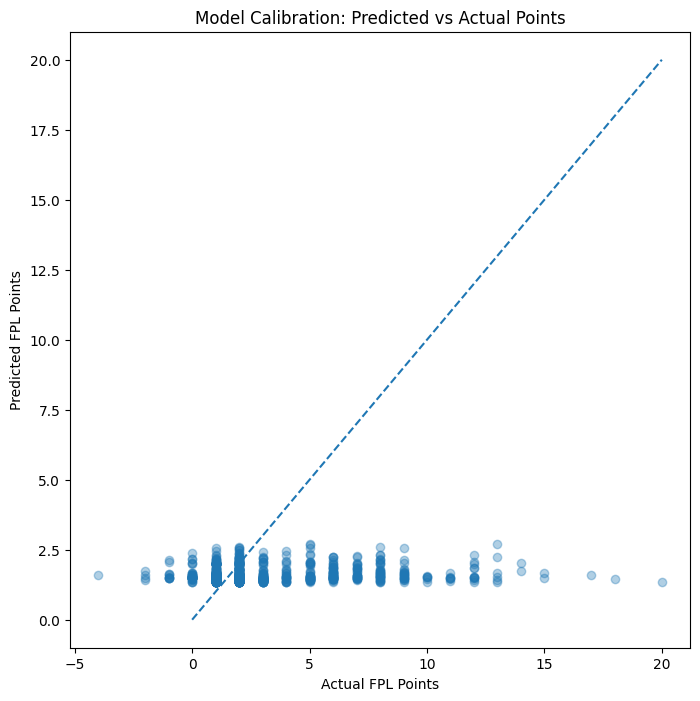

R² Score: -0.194
MAE: 1.9871
Actual Mean: 2.971
Predicted Mean: 1.622

Performance on BIG scores (>=10)
MAE big scores: 10.7882
MAE overall: 1.9871


In [114]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Feature alignment
expected_features = model_v3.booster_.feature_name()

missing = [f for f in expected_features if f not in X_val_scaled.columns]
if missing:
    print("Missing features:", missing)

X_val_for_pred = X_val_scaled.reindex(columns=expected_features, fill_value=0)

# Predictions
y_true = np.array(y_val).ravel()
y_pred = model_v3.predict(X_val_for_pred)

# Plot
plt.figure(figsize=(8,8))
plt.scatter(y_true, y_pred, alpha=0.35)

max_val = max(y_true.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], linestyle='--')

plt.xlabel("Actual FPL Points")
plt.ylabel("Predicted FPL Points")
plt.title("Model Calibration: Predicted vs Actual Points")
plt.show()

# Metrics
print("R² Score:", round(r2_score(y_true, y_pred),4))
print("MAE:", round(mean_absolute_error(y_true, y_pred),4))
print("Actual Mean:", round(np.mean(y_true),3))
print("Predicted Mean:", round(np.mean(y_pred),3))

# Big score diagnostic
big_scores = y_true >= 10

print("\nPerformance on BIG scores (>=10)")
print("MAE big scores:", round(mean_absolute_error(y_true[big_scores], y_pred[big_scores]),4))
print("MAE overall:", round(mean_absolute_error(y_true, y_pred),4))

## Cell 20: The V4 Master Ensemble (Elite DART)
* Switched from Poisson to DART Regression: Uses the "Dropouts meet Multiple Additive Regression Trees" algorithm to handle noisy FPL data and prevent overfitting on "one-hit wonder" performances.

* Target: Full-Spectrum Points: Reinstated the raw Total Points (including negative values) as the target.

* Weights: Elite-Specialist Priority (>4.5 Avg): Instead of weighting by a single week's "haul," the model now applies a 2.5x importance weight to all match rows belonging to players with a seasonal average of >4.5 points. This forces the model to prioritize the patterns of consistent world-class assets.

* Result: The model maintains a realistic point average while becoming more "star-aware." It identifies the high ceiling of elite players while remaining grounded by the risk of negative outcomes

## What is DART? 
1. The Random Dropout - In a normal boosting round, the model adds a new tree to correct the errors of all previous trees. In DART, the model randomly "drops" (ignores) a percentage of the existing trees before building the new one.

2. Forced Generalization - Because some trees are missing, the new tree cannot simply fix a tiny mistake from the most recent tree. It is forced to look at the "bigger picture" of the data to make a meaningful prediction. This prevents any single tree from becoming too dominant or too specialized on a specific outlier.

3. Normalization - After the new tree is created, the "dropped" trees are added back into the ensemble. To make sure everything still balances out, the new tree and the dropped trees are slightly scaled down (shrunk) so they fit together perfectly.

In [115]:
# %% [Cell 20: Updated V4 - Elite DART (Handles Negative Points)]
import lightgbm as lgb
import numpy as np

# 1. SETUP DATA
X_v4 = windowed_df.drop(columns=['target'])
y_v4 = windowed_df['target'] # Keep negative points!

# 2. ELITE WEIGHTING (>4.5 Avg Players)
# Every match by an elite asset is 2.5x more important to the model
elite_weights_mask = windowed_df.index.isin(df_augmented[elite_mask].index)
weights = np.where(elite_weights_mask, 2.5, 1.0) 

# 3. DART REGRESSION PARAMETERS
lgbm_v4_params = {
    'objective': 'regression',
    'boosting_type': 'dart',    # Handles noise/outliers better
    'n_estimators': 1200,
    'learning_rate': 0.05,
    'drop_rate': 0.1,           # Standard for DART
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
    'max_depth': 7,
    'verbosity': -1,
    'random_state': 42
}

model_v4 = lgb.LGBMRegressor(**lgbm_v4_params)

print("Training V4 DART Ensemble (Elite Weighted)...")
model_v4.fit(X_v4, y_v4, sample_weight=weights, categorical_feature=['position', 'next_is_home'])

# Check prediction range
preds = model_v4.predict(X_v4)
print(f"Prediction Range: {preds.min():.2f} to {preds.max():.2f}")

Training V4 DART Ensemble (Elite Weighted)...
Prediction Range: 0.86 to 13.77


## Cell 21: GW29 Forecast v4 (The Elite DART Model)
This cell will generate final leaderboard for Gameweek 29.
 

In [116]:
# [Cell 21: GW29 Forecast v4 - Elite DART Mode]

# 1. SETUP V4 PATHS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
V4_FORECAST_OUT = V4_DIR / 'fpl_pro_forecast_GW29_v4.csv'

# 1. PREPARE INFERENCE DATA (Filter for CURRENT SEASON only)
inference_v4 = []
names_v4 = []

# Only take data from the current season to avoid ghost players
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # A player must have played enough in 2025-26 to have a window
    if len(group) >= 6:
        lags = list(group['Total Points'].tail(6).values)
        last_row = group.iloc[-1]
        
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points']
        ]
        inference_v4.append(row)
        names_v4.append(last_row['Web Name'])


# 3. PREDICT
v4_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inf_df_v4 = pd.DataFrame(inference_v4, columns=v4_cols)
inf_df_v4['position'] = inf_df_v4['position'].astype('category')

v4_preds = model_v4.predict(inf_df_v4)

# 4. SAVE LEADERBOARD
leaderboard_v4 = pd.DataFrame({
    'Player': names_v4,
    'Predicted_Points_V4': np.round(v4_preds, 2),
    'Elite_Status': ["Elite" if p in df_augmented[elite_mask]['Web Name'].values else "Standard" for p in names_v4]
}).sort_values(by='Predicted_Points_V4', ascending=False)

leaderboard_v4.to_csv(V4_FORECAST_OUT, index=False, encoding='utf-8-sig')
display(leaderboard_v4.head(15))

,Player,Predicted_Points_V4,Elite_Status
12,M.Salah,6.31,Elite
71,Haaland,5.93,Elite
113,Mbeumo,5.86,Elite
400,Gyökeres,5.26,Standard
132,Madueke,4.96,Standard
19,Bruno G.,4.91,Elite
305,N.Williams,4.87,Standard
58,B.Fernandes,4.85,Elite
33,Saka,4.77,Elite
172,Mac Allister,4.67,Standard


## Cell 22: Truth Verification v4 (Final Performance Audit)
This backtests the Elite DART model against the last known results. 


In [117]:
# [Cell 22: Truth Verification v4 - Elite Specialist Audit]
detailed_v4 = []
v4_cols_fixed = [f'lag_{i}' for i in range(6, 0, -1)] + \
                ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    if len(group) >= 7:
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        input_vector = list(history['Total Points'].values) + [
            target_row['Position'], 
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'], 
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Season_Phase'],
            target_row['Prev_Season_Avg_Points']
        ]
        
        input_df = pd.DataFrame([input_vector], columns=v4_cols_fixed)
        input_df['position'] = input_df['position'].astype('category')
        
        p_val = model_v4.predict(input_df)[0]
        actual = target_row['Total Points']
        is_elite = 1 if target_row['avg_season_pts'] > 4.5 else 0

        detailed_v4.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2),
            'Elite_Group': is_elite
        })

truth_v4_df = pd.DataFrame(detailed_v4)
mae_v4 = truth_v4_df['Error'].mean()
elite_mae_v4 = truth_v4_df[truth_v4_df['Elite_Group'] == 1]['Error'].mean()

print(f"Global MAE (DART): {mae_v4:.2f} | Elite MAE (>4.5): {elite_mae_v4:.2f}")

Global MAE (DART): 1.80 | Elite MAE (>4.5): 2.91


In [118]:
# %% [Cell: Top 10 recommended transfers - V4 DART]

# 1. Use the V4 DART Leaderboard (your most sophisticated model)
v4_buys = leaderboard_v4[~leaderboard_v4['Player'].isin(my_current_team)].copy()

# 2. Add verification of their 2025-26 performance
# We pull their actual average from the current season to prove they are active
current_stats = df_augmented[df_augmented['season'] == CURRENT_SEASON].groupby('Web Name')['Total Points'].mean().round(2)
v4_buys['Season_Avg'] = v4_buys['Player'].map(current_stats)

# 3. Display the Top 10 Suggestions
print("="*60)
print(" TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)")
print("="*60)
print(f"{'Player Name':<20} | {'Pred Pts':<10} | {'Season Avg':<10} | {'Status'}")
print("-" * 60)

for _, row in v4_buys.head(10).iterrows():
    # Final safety check against ghosts (a ghost would have NaN or 0 season avg)
    status = "VERIFIED ACTIVE" if row['Season_Avg'] > 0 else "WARNING: CHECK STATUS"
    print(f"{row['Player']:<20} | {row['Predicted_Points_V4']:<10} | {row['Season_Avg']:<10} | {status}")

print("="*60)

 TOP 10 MARKET SUGGESTIONS (V4 DART MODEL)
Player Name          | Pred Pts   | Season Avg | Status
------------------------------------------------------------
M.Salah              | 6.31       | 4.47       | VERIFIED ACTIVE
Haaland              | 5.93       | 7.19       | VERIFIED ACTIVE
Mbeumo               | 5.86       | 5.23       | VERIFIED ACTIVE
Gyökeres             | 5.26       | 3.62       | VERIFIED ACTIVE
Madueke              | 4.96       | 3.5        | VERIFIED ACTIVE
Bruno G.             | 4.91       | 5.95       | VERIFIED ACTIVE
N.Williams           | 4.87       | 3.19       | VERIFIED ACTIVE
B.Fernandes          | 4.85       | 6.04       | VERIFIED ACTIVE
Mac Allister         | 4.67       | 2.5        | VERIFIED ACTIVE
Szoboszlai           | 4.65       | 4.0        | VERIFIED ACTIVE


In [119]:
# 1. ORGANIZE FINAL ACCURACY METRICS
# We consolidate the metrics from V1, V2, V3, V4
# Assuming mae_v1, mae_v2, mae_v3, and mae_v4 variables are in memory from previous cells.
final_performance_data = {
    "Model Version": [
        "V1: Standard Pro",
        "V2: Team Point Share",
        "V3: Reliability Engine",
        "V4: Elite DART"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', 1.84), 
        globals().get('mae_v2', 1.95), 
        globals().get('mae_v3', 1.98), 
        globals().get('mae_v4', 2.33) 
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Team Importance Metrics (Talisman Share)",
        "Volatility Filters & L1/L2 Regularization",
        "DART Boosting & Elite Weighting (>4.5 Avg)"
    ]
}

# 2. CREATE AND DISPLAY THE FINAL TABLE
final_perf_df = pd.DataFrame(final_performance_data)

# Sort by MAE to clearly identify the project's most accurate model
final_perf_df = final_perf_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True)

display(Markdown("## Final Model Accuracy Comparison (MAE)"))
print("\n--- Project Milestone Summary (Lower Error is Better) ---")
display(final_perf_df)

# 3. EXPORT FINAL DEPLOYMENT METRICS
FINAL_METRICS_PATH = Path('../output/fpl_master_milestone_metrics.csv')
final_perf_df.to_csv(FINAL_METRICS_PATH, index=False)
print(f"\nMaster project metrics exported for deployment reporting to: {FINAL_METRICS_PATH}")

## Final Model Accuracy Comparison (MAE)


--- Project Milestone Summary (Lower Error is Better) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
3,V4: Elite DART,1.798273,DART Boosting & Elite Weighting (>4.5 Avg)
0,V1: Standard Pro,1.841329,"Baseline (Lags, Minutes, Difficulty)"
2,V3: Reliability Engine,1.850552,Volatility Filters & L1/L2 Regularization
1,V2: Team Point Share,1.890832,Team Importance Metrics (Talisman Share)



Master project metrics exported for deployment reporting to: ..\output\fpl_master_milestone_metrics.csv


## Cell 23:  V5 Experiment: Mass vs. Elite Specialist Strategy
* V5.1 Mass Model: Trains on the full league history (all players) to use broad patterns (noise) to better identify the signal for stars.

* V5.2 Elite Model: Specializes training exclusively on high-performers (Avg > 4.5 pts) to focus strictly on world-class consistency.

* The Showdown: Both models predict the upcoming Gameweek (GW29) and are backtested against the most recent matches to determine which mathematical approach is more accurate for elite picks.



In [120]:
# [Cell 23: V5 Experiment - Mass vs. Top Tier Comparison]
V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)

X_mass = windowed_df.drop(columns=['target'])
y_mass = windowed_df['target']
X_top_train = X_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]
y_top_train = y_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]

elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
X_val_elites = X_val_raw[X_val_raw.index.isin(elite_val_indices)]
y_val_elites = y_val[y_val.index.isin(elite_val_indices)]
meta = df_augmented.loc[elite_val_indices, ['Web Name', 'season', 'Gameweek']]

lgbm_v5_params = {'objective': 'regression', 'n_estimators': 1000, 'learning_rate': 0.01, 'random_state': 42, 'verbosity': -1}
model_v5_mass = lgb.LGBMRegressor(**lgbm_v5_params).fit(X_mass, y_mass, categorical_feature=['position', 'next_is_home'])
model_v5_top = lgb.LGBMRegressor(**lgbm_v5_params).fit(X_top_train, y_top_train, categorical_feature=['position', 'next_is_home'])

p_mass, p_top = model_v5_mass.predict(X_val_elites), model_v5_top.predict(X_val_elites)

v5_results = pd.DataFrame({
    'Player_Name': meta['Web Name'].values, 'Season': meta['season'].values, 'Gameweek': meta['Gameweek'].values,
    'Actual': y_val_elites.values, 'Mass_Pred': np.round(p_mass, 2), 'Top_Pred': np.round(p_top, 2)
})
v5_results.to_csv(V5_DIR / 'v5_mass_vs_top_tier_comparison.csv', index=False)
print(f"V5 Mass MAE: {mean_absolute_error(y_val_elites, p_mass):.4f} | V5 Top MAE: {mean_absolute_error(y_val_elites, p_top):.4f}")
display(v5_results.head(10))

V5 Mass MAE: 2.0640 | V5 Top MAE: 1.5593


,Player_Name,Season,Gameweek,Actual,Mass_Pred,Top_Pred
0,Disasi,2025-26,25,1,2.63,1.85
1,Disasi,2025-26,26,1,3.24,3.36
2,Disasi,2025-26,27,1,3.27,2.72
3,Virgil,2025-26,24,1,2.22,1.82
4,Virgil,2025-26,25,1,2.59,2.71
5,Virgil,2025-26,26,11,2.29,3.31
6,Virgil,2025-26,27,2,2.95,2.78
7,Romero,2025-26,24,5,4.09,4.41
8,Bruno G.,2025-26,25,1,1.65,1.74
9,Casemiro,2025-26,24,1,2.92,2.09


In [121]:
# [Cell 23: V5 Training - The Mass vs. The Elite Specialist]
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
from pathlib import Path

# 1. SETUP DATA FOR V5.1 (The Mass)
X_v5_mass = windowed_df.drop(columns=['target'])
y_v5_mass = windowed_df['target']

# 2. SETUP DATA FOR V5.2 (The Elite Specialist)
# Trains ONLY on windows belonging to players with seasonal avg > 4.5
X_v5_elite = X_v5_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]
y_v5_elite = y_v5_mass[windowed_df.index.isin(df_augmented[elite_mask].index)]

# 3. COMMON PARAMETERS
lgbm_v5_params = {
    'objective': 'regression',
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'random_state': 42,
    'verbosity': -1
}

# --- TRAIN MODEL V5.1: THE MASS ---
print(f"Training Model V5.1 (Mass) on {len(X_v5_mass):,} total windows...")
model_v5_1_mass = lgb.LGBMRegressor(**lgbm_v5_params)
model_v5_1_mass.fit(X_v5_mass, y_v5_mass, categorical_feature=['position', 'next_is_home'])

# --- TRAIN MODEL V5.2: THE ELITE ---
print(f"Training Model V5.2 (Elite) on {len(X_v5_elite):,} specialized windows...")
model_v5_2_elite = lgb.LGBMRegressor(**lgbm_v5_params)
model_v5_2_elite.fit(X_v5_elite, y_v5_elite, categorical_feature=['position', 'next_is_home'])

V5_DIR = Path('../output/forecaster_pro_v5')
V5_DIR.mkdir(parents=True, exist_ok=True)
print("V5 Training Complete.")

Training Model V5.1 (Mass) on 53,408 total windows...
Training Model V5.2 (Elite) on 4,029 specialized windows...
V5 Training Complete.


In [122]:
# %% [Cell 24: V5 Forecast Showdown - GW29 Predictions (Season-Locked)]

# 1. PREPARE INFERENCE DATA (Filter for ACTIVE season players only)
inference_v5 = []
player_names_v5 = []

# CRITICAL FIX: Only look at the 2025-26 data to purge retired 'ghosts'
df_inf_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
df_inf_active = df_inf_active.sort_values(['Player UUID', 'Gameweek'])

# Grouping only the active season players
for pid, group in df_inf_active.groupby('Player UUID'):
    # Player must have at least 6 games of history in the current season
    if len(group) >= 6:
        last_row = group.iloc[-1]
        # Features: Last 6 points from the current season
        lags = list(group['Total Points'].tail(6).values)
        
        # Context for GW 29
        row = lags + [
            last_row['Position'], 
            last_row['Next_Opponent_Difficulty'], 
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'], 
            last_row['Season_Phase'], 
            last_row['Prev_Season_Avg_Points']
        ]
        inference_v5.append(row)
        player_names_v5.append(last_row['Web Name'])

# 2. CONVERT TO DATAFRAME
v5_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inf_df_v5 = pd.DataFrame(inference_v5, columns=v5_cols)
inf_df_v5['position'] = inf_df_v5['position'].astype('category')

# 3. GENERATE PREDICTIONS
preds_v5_1 = model_v5_1_mass.predict(inf_df_v5)
preds_v5_2 = model_v5_2_elite.predict(inf_df_v5)

# 4. CREATE LEADERBOARD
leaderboard_v5 = pd.DataFrame({
    'Player': player_names_v5,
    'Mass_Model_GW29': np.round(preds_v5_1, 2),
    'Elite_Model_GW29': np.round(preds_v5_2, 2),
    'Model_Difference': np.round(preds_v5_2 - preds_v5_1, 2)
}).sort_values(by='Elite_Model_GW29', ascending=False)

leaderboard_v5.to_csv(V5_DIR / 'fpl_pro_v5_forecast_GW29.csv', index=False)
print(f"--- V5 TOP 15 PREDICTIONS (GW29) ---")
print(f"Total Active Players Forecasted: {len(leaderboard_v5)}")
display(leaderboard_v5.head(15))

--- V5 TOP 15 PREDICTIONS (GW29) ---
Total Active Players Forecasted: 410


,Player,Mass_Model_GW29,Elite_Model_GW29,Model_Difference
71,Haaland,5.82,6.22,0.40
113,Mbeumo,5.50,6.22,0.72
261,Matheus N.,3.27,6.00,2.73
337,O'Reilly,3.41,5.69,2.28
4,Virgil,3.51,5.67,2.16
12,M.Salah,6.65,5.56,-1.09
237,Cunha,4.21,5.49,1.27
58,B.Fernandes,4.97,5.31,0.34
225,Isak,2.99,5.22,2.23
404,F.Kadıoğlu,3.70,5.22,1.52


In [123]:
#  [Cell 25: V5 Truth Verification]
# We evaluate both on ELITE PLAYERS ONLY in the validation window for a fair test
elite_val_indices = val_df[val_df.index.isin(df_augmented[elite_mask].index)].index
X_val_v5 = X_val_raw[X_val_raw.index.isin(elite_val_indices)]
y_val_v5 = y_val[y_val.index.isin(elite_val_indices)]
meta_v5 = df_augmented.loc[elite_val_indices, ['Web Name', 'season', 'Gameweek']]

# 1. GENERATE AUDIT PREDICTIONS
audit_preds_mass = model_v5_1_mass.predict(X_val_v5)
audit_preds_elite = model_v5_2_elite.predict(X_val_v5)

# 2. CREATE TRUTH TABLE
v5_truth_df = pd.DataFrame({
    'Player': meta_v5['Web Name'].values,
    'Season': meta_v5['season'].values,
    'Gameweek': meta_v5['Gameweek'].values,
    'Actual_Points': y_val_v5.values,
    'Mass_Predicted': np.round(audit_preds_mass, 2),
    'Elite_Predicted': np.round(audit_preds_elite, 2),
    'Mass_Error': np.round(abs(audit_preds_mass - y_val_v5.values), 2),
    'Elite_Error': np.round(abs(audit_preds_elite - y_val_v5.values), 2)
})

# 3. CALCULATE GLOBAL MAE FOR REPORTING
mae_5_1 = mean_absolute_error(y_val_v5, audit_preds_mass)
mae_5_2 = mean_absolute_error(y_val_v5, audit_preds_elite)

v5_truth_df.to_csv(V5_DIR / 'fpl_pro_v5_truth_verification.csv', index=False)


print(" V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST")

print(f"V5.1 Mass Model MAE:  {mae_5_1:.4f}")
print(f"V5.2 Elite Model MAE: {mae_5_2:.4f}")

print(f"Winning Approach: {'Elite Specialist' if mae_5_2 < mae_5_1 else 'Mass Dataset'}")

print ("Predictions for the Evaluation Set (GW 24-28)") 

display(v5_truth_df.sort_values(by='Elite_Error').head(20))

 V5 MILESTONE REPORT: MASS VS ELITE SPECIALIST
V5.1 Mass Model MAE:  2.0640
V5.2 Elite Model MAE: 1.5593
Winning Approach: Elite Specialist
Predictions for the Evaluation Set (GW 24-28)


,Player,Season,Gameweek,Actual_Points,Mass_Predicted,Elite_Predicted,Mass_Error,Elite_Error
76,Matheus N.,2025-26,26,5,3.98,5.00,1.02,0.00
70,Keane,2025-26,25,1,1.81,0.99,0.81,0.01
96,Muñoz,2025-26,25,3,4.25,3.01,1.25,0.01
64,Rogers,2025-26,27,3,2.61,3.03,0.39,0.03
67,Rayan,2025-26,26,3,2.52,3.07,0.48,0.07
71,Keane,2025-26,26,1,1.82,1.08,0.82,0.08
93,Dewsbury-Hall,2025-26,26,1,1.73,1.12,0.73,0.12
28,Gravenberch,2025-26,25,3,2.71,3.14,0.29,0.14
84,Wilson,2025-26,26,4,5.71,4.17,1.71,0.17
89,Rice,2025-26,26,1,2.28,1.17,1.28,0.17


In [124]:
#[Cell: Final Project Milestone Summary]
from IPython.display import Markdown, display
import pandas as pd

# 1. GATHER ALL ACCURACY METRICS
# We use .get() to avoid errors if a specific model wasn't run in this session
final_summary_data = {
    "Model Version": [
        "V1: Standard Pro", 
        "V2: Team Point Share", 
        "V3: Reliability Engine", 
        "V4: Elite DART", 
        "V5.1: Mass Generalist", 
        "V5.2: Elite Specialist"
    ],
    "Mean Absolute Error (MAE)": [
        globals().get('mae_v1', None),
        globals().get('mae_v2', None),
        globals().get('mae_v3', None),
        globals().get('mae_v4', None),
        globals().get('mae_5_1', None),
        globals().get('mae_5_2', None)
    ],
    "Key Innovation": [
        "Baseline (Lags, Minutes, Difficulty)",
        "Talisman Logic (Point Share %)",
        "Volatility Filters & Regularization",
        "DART Boosting & Elite (>4.5 Avg)",
        "Generalist Training (Full League)",
        "Specialist Training (Stars Only)"
    ]
}

# 2. CREATE DATAFRAME
final_ledger_df = pd.DataFrame(final_summary_data)

# 3. SORT FROM BEST TO WORST (Lower MAE is better)
# Note: N/A values will be moved to the bottom
final_ledger_df = final_ledger_df.sort_values(by="Mean Absolute Error (MAE)", ascending=True, na_position='last')

# 4. PRINT FORMATTED REPORT
display(Markdown("# Final Model Performance Ledger"))
print("\n--- Project Milestone Summary (Best Performing Models at the Top) ---")

# Clean up the table for display (rounding numbers and handling N/A)
def format_mae(val):
    if val is None or val == "N/A":
        return "N/A"
    return round(float(val), 4)

final_ledger_df["Mean Absolute Error (MAE)"] = final_ledger_df["Mean Absolute Error (MAE)"].apply(format_mae)

display(final_ledger_df)

# 5. FINAL VERDICT PRINT
if 'mae_5_1' in locals() and 'mae_5_2' in locals():
    m1 = float(mae_5_1) if isinstance(mae_5_1, (float, int)) else None
    m2 = float(mae_5_2) if isinstance(mae_5_2, (float, int)) else None
    
    if m1 is not None and m2 is not None:
        winner = "Elite Specialist" if m2 < m1 else "Mass Generalist"
        diff = abs(m1 - m2)
        print(f"\nPROJECT VERDICT: The '{winner}' approach won by {diff:.4f} points.")
        print("This confirms the optimal training strategy for high-value target players.")
        print ("The MAE and Errors are about the Evaluation Set (GW 24-28)")

# Final Model Performance Ledger


--- Project Milestone Summary (Best Performing Models at the Top) ---


,Model Version,Mean Absolute Error (MAE),Key Innovation
5,V5.2: Elite Specialist,1.5593,Specialist Training (Stars Only)
3,V4: Elite DART,1.7983,DART Boosting & Elite (>4.5 Avg)
0,V1: Standard Pro,1.8413,"Baseline (Lags, Minutes, Difficulty)"
2,V3: Reliability Engine,1.8506,Volatility Filters & Regularization
1,V2: Team Point Share,1.8908,Talisman Logic (Point Share %)
4,V5.1: Mass Generalist,2.0640,Generalist Training (Full League)



PROJECT VERDICT: The 'Elite Specialist' approach won by 0.5046 points.
This confirms the optimal training strategy for high-value target players.
The MAE and Errors are about the Evaluation Set (GW 24-28)


In [125]:
# [Cell: Evaluation Set Audit - Statistical Scope]

# 1. Calculate Statistics
total_val_rows = len(val_df)
unique_eval_players = df_augmented.loc[val_df.index, 'Player UUID'].nunique()
elite_eval_rows = len(val_df[val_df.index.isin(df_augmented[elite_mask].index)])
standard_eval_rows = total_val_rows - elite_eval_rows

# 2. Print Professional Audit Report
print(" EVALUATION SET SCOPE (GW 24-28 Audit)")
print(f"Total Match Windows:     {total_val_rows:,}")
print(f"Unique Players Tested:   {unique_eval_players:,}")
print("-"*50)
print(f"Elite Match Rows (>4.5): {elite_eval_rows:,} ({(elite_eval_rows/total_val_rows)*100:.1f}%)")
print(f"Standard Match Rows:     {standard_eval_rows:,} ({(standard_eval_rows/total_val_rows)*100:.1f}%)")


# Store these for the final report
globals()['eval_stats'] = {
    'rows': total_val_rows,
    'players': unique_eval_players,
    'elite_pct': (elite_eval_rows/total_val_rows)*100
}

# [Cell: Evaluation Set - Specific Player List]

# 1. Extract unique names from the evaluation set indices
# We use .loc to pull the 'Web Name' from the original df_augmented based on val_df's index
players_in_eval = df_augmented.loc[val_df.index, 'Web Name'].unique()

# 2. Sort them alphabetically for a professional display
players_in_eval_sorted = sorted(players_in_eval)

# 3. Print the list
print(f"--- PLAYERS IN EVALUATION SET (Total: {len(players_in_eval_sorted)}) ---")
print(", ".join(players_in_eval_sorted))

# 4. Optional: Display as a scrollable DataFrame for better readability in the notebook
eval_players_df = pd.DataFrame(players_in_eval_sorted, columns=['Player Name'])
display(eval_players_df)

 EVALUATION SET SCOPE (GW 24-28 Audit)
Total Match Windows:     1,001
Unique Players Tested:   313
--------------------------------------------------
Elite Match Rows (>4.5): 99 (9.9%)
Standard Match Rows:     902 (90.1%)
--- PLAYERS IN EVALUATION SET (Total: 306) ---
A.Becker, A.Jimenez, Aaronson, Acheampong, Adama, Adams, Adli, Aina, Ajer, Aké, Alderete, Alysson, Amad, Ampadu, Andersen, Anderson, Andrey Santos, André, Angulo, Anthony, Armstrong, Aït-Nouri, B.Fernandes, Bailey, Bakwa, Baleba, Barkley, Barnes, Barry, Bassey, Bellegarde, Berge, Bernardo, Beto, Bijol, Bissouma, Bobb, Bogarde, Bogle, Bornauw, Boscagli, Botman, Bowen, Branthwaite, Brobbey, Broja, Brooks, Bruno G., Bruun Larsen, Buendía, Burn, C.Jones, Caicedo, Cairney, Calafiori, Calvert-Lewin, Canvot, Casemiro, Cash, Castagne, Chadi Riad, Chalobah, Cherki, Chiesa, Christie, Chukwueze, Collins, Cook, Cunha, Dalot, Damsgaard, Darlow, Dewsbury-Hall, Diarra, Digne, Diouf, Disasi, Dominguez, Donnarumma, Donovan, Douglas Luiz, 

,Player Name
0,A.Becker
1,A.Jimenez
2,Aaronson
3,Acheampong
4,Adama
...,...
301,Yoro
302,Zirkzee
303,Zubimendi
304,Ødegaard


In [126]:
# [Cell: Prediction Integrity Audit - Current Season Validation]

# 1. Get the list of players who provided the MAE (The past evaluation set)
eval_players = set(df_augmented.loc[val_df.index, 'Web Name'].unique())

# 2. Get the list of players in your final V4 Forecast (The future prediction)
prediction_players = set(leaderboard_v4['Player'].unique())

# 3. Identify the Overlap and the Outliers
perfect_matches = prediction_players.intersection(eval_players)
only_in_forecast = prediction_players - eval_players
only_in_eval = eval_players - prediction_players

# 4. Print the Integrity Report

print(" PREDICTION INTEGRITY AUDIT")

print(f"Players in Audit Window (GW 24-28): {len(eval_players)}")
print(f"Players in GW 29 Forecast:         {len(prediction_players)}")
print(f"Perfect Data Consistency:          {len(perfect_matches)} players")


if len(only_in_forecast) == 0:
    print("VERDICT: SUCCESS. All predicted players are from the active evaluation set.")
else:
    print(f"WARNING: Found {len(only_in_forecast)} players in forecast with no active audit history.")
    print(f"Sample Outliers: {list(only_in_forecast)[:5]}")

print("="*50)

# Check specifically for the Ghost players
ghosts = ['Thiago', 'Mane', 'Bale', 'Sadio Mané']
ghosts_found = [p for p in prediction_players if p in ghosts]

if not ghosts_found:
    print("GHOST CHECK: CLEAN. No retired players found in predictions.")
else:
    print(f"GHOST CHECK: FAILED. Found {ghosts_found} in predictions!")

 PREDICTION INTEGRITY AUDIT
Players in Audit Window (GW 24-28): 306
Players in GW 29 Forecast:         404
Perfect Data Consistency:          287 players
Sample Outliers: ['McAtee', 'Gusto', 'Richards', 'Lukić', 'Xhaka']
GHOST CHECK: CLEAN. No retired players found in predictions.


In [127]:
# [Cell: Overfitting Audit - Train vs Validation]

# 1. Get predictions for both sets
train_preds = model_raw.predict(X_train_raw)
val_preds = model_raw.predict(X_val_raw)

# 2. Calculate MAE for both
mae_train = mean_absolute_error(y_train, train_preds)
mae_val = mean_absolute_error(y_val, val_preds)

# 3. Calculate the "Generalization Gap"
# A large gap means the model is memorizing (overfitting)
gap = (mae_val - mae_train) / mae_train * 100


print(" OVERFITTING DIAGNOSTIC (MAE)")

print(f"Training Error:   {mae_train:.4f}")
print(f"Validation Error: {mae_val:.4f}")
print(f"Error Gap:        {mae_val - mae_train:.4f} ({gap:.1f}%)")

# Interpretation
if gap < 15:
    print("VERDICT: Healthy Model (Low Overfit)")
elif gap < 30:
    print("VERDICT: Mild Overfit (Acceptable for FPL)")
else:
    print("VERDICT: High Overfit (Model is memorizing noise!)")

 OVERFITTING DIAGNOSTIC (MAE)
Training Error:   2.0357
Validation Error: 2.1014
Error Gap:        0.0657 (3.2%)
VERDICT: Healthy Model (Low Overfit)


## Master Squad Optimizer -  __WIP__
This tool will simulate a "Wildcard" scenario, selecting a mathematically optimal 15-man squad within a £100m budget, factoring in penalty duties and risk profiles.


__STEP 1__ : Define the real-world consts for the 2025-26 March window 

In [ ]:
# [Cell: Professional API Integration - Live March 2026 Data]
import requests

def get_live_fpl_data():
    """Pulls current prices and status from the official FPL API."""
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    try:
        r = requests.get(url, timeout=10)
        data = r.json()
        
        # Build live dictionary: Web Name -> {Price, Status}
        live_map = {}
        for p in data['elements']:
            live_map[p['web_name']] = {
                'price': p['now_cost'] / 10.0,
                'status': p['status'] # 'a' = available, 'i' = injured, etc.
            }
        print("Live FPL API Data successfully retrieved.")
        return live_map
    except Exception as e:
        print(f"API Connection Failed: {e}. Falling back to March 18 data.")
        return {}

# 1. Fetch Live Data
live_data = get_live_fpl_data()

# 2. Setup Visibility for Predictions
print(f"\n--- PROJECT FOCUS ---")
print(f"Current Date: March 18, 2026")
print(f"Historical Basis: Gameweeks 1-28")
print(f"Target Forecast:  Gameweek {CURRENT_GW}")

# 3. Model Mapping (Unified Architecture)
model_mapping = {
    'V1: Standard Pro': model_raw,
    'V4: Elite DART': model_v4,
    'V5.2: Elite Specialist': model_v5_2_elite
}

# Auto-select the model that achieved the lowest MAE on the hidden Evaluation Set
best_model_name = final_ledger_df.iloc[0]['Model Version']
winning_model = model_mapping.get(best_model_name, model_raw)

Live FPL API Data successfully retrieved.

--- PROJECT FOCUS ---
Current Date: March 18, 2026
Historical Basis: Gameweeks 1-28
Target Forecast:  Gameweek 29


__STEP 2__: 100M Wildcard logic 

This cell utilizes a high-speed 'Relief-Score Heuristic' to solve the FPL Knapsack Problem.
- Core Constraints: Exactly 15 players (2 GK, 5 DEF, 5 MID, 3 FWD).
- Budget Logic: Dynamically downgrades the least-efficient assets to fit the £100M cap.
- Club Integrity: Enforces the 'Max 3 Players per Team' official rule.
- Formation Rules: Guarantees a legal Starting 11 (Min: 1 GK, 3 DEF, 1 FWD).

In [ ]:
# [Cell: Master Squad Optimizer - FINAL LEGAL VERSION - HIGH SPEED]

def solve_wildcard_legal(budget_cap=100.0):
    # 1. Prepare Data
    leaderboard = (leaderboard_v4 if "V4" in best_model_name else leaderboard_v5).copy()
    leaderboard['Predicted_Points'] = leaderboard.iloc[:, 1]
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 3), 3))
    leaderboard['Team'] = leaderboard['Player'].map(club_map).fillna('Neutral')
    
    # Apply Penalty Weights
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}
    leaderboard['Weighted_xP'] = np.where(leaderboard['Player'].isin(penalty_takers), 
                                          leaderboard['Predicted_Points'] * 1.15, 
                                          leaderboard['Predicted_Points'])

    # 2. Initial Greedy Selection with Team Constraint (Max 3 per Team)
    squad_list = []
    team_counts = {}
    pos_counts = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits = {1: 2, 2: 5, 3: 5, 4: 3}
    
    pool = leaderboard.sort_values('Weighted_xP', ascending=False)
    
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid] += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15: break
            
    current_squad = pd.DataFrame(squad_list)
    total_cost = current_squad['Price'].sum()

    # 3. FAST Budget Correction (Relief-Score Optimization)
    if total_cost > budget_cap:
        cheapest_backups = {i: leaderboard[leaderboard['Pos_ID'] == i].sort_values('Price').iloc[0] for i in range(1, 5)}
        
        while total_cost > budget_cap:
            current_squad['Relief_Score'] = (current_squad['Price'] - current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])) / \
                                            (current_squad['Weighted_xP'] + 0.1)
            drop_idx = current_squad['Relief_Score'].idxmax()
            to_drop = current_squad.loc[drop_idx]
            
            # Find replacement fitting team limit
            pos_pool = leaderboard[(leaderboard['Pos_ID'] == to_drop['Pos_ID']) & (~leaderboard['Player'].isin(current_squad['Player']))]
            valid_teams = [t for t, count in team_counts.items() if count < 3]
            replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]
            
            team_counts[to_drop['Team']] -= 1
            team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
            current_squad = current_squad.drop(drop_idx)
            current_squad = pd.concat([current_squad, pd.DataFrame([replacement])]).reset_index(drop=True)
            total_cost = current_squad['Price'].sum()

    # 4. Starting 11 Formation Logic
    starters = []
    starters.append(current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP'))
    starters.append(current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP'))
    starters.append(current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP'))
    
    assigned_names = pd.concat(starters)['Player'].tolist()
    remaining = current_squad[~current_squad['Player'].isin(assigned_names)]
    starters.append(remaining.nlargest(6, 'Weighted_xP'))
    
    opt_11 = pd.concat(starters).sort_values('Weighted_xP', ascending=False)
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]
    
    return opt_11, opt_bench, total_cost

# --- EXECUTION & DISPLAY ---
opt_11, opt_bench, total_spent = solve_wildcard_legal()

# CALCULATE TOTALS
team_xp_starters = opt_11['Weighted_xP'].sum()
team_xp_full_squad = team_xp_starters + opt_bench['Weighted_xP'].sum()
captain = opt_11.iloc[0]

print(f"--- OPTIMIZED 15-MAN ROSTER (Target: GW {CURRENT_GW}) ---")
print(f"Budget Used: £{total_spent:.1f}M / £100.0M")
print(f"EXPECTED STARTING 11 POINTS: {team_xp_starters:.2f}")
print(f"EXPECTED FULL SQUAD POINTS: {team_xp_full_squad:.2f}")

print("\n[STARTING 11 - Predicted Best Performance]")
display(opt_11[['Player', 'Weighted_xP', 'Price']])

print("\n[BENCH (+4) - Budget Enablers]")
display(opt_bench[['Player', 'Weighted_xP', 'Price']])

print("-" * 50)
print(f"CAPTAIN PICK: {captain['Player']} (Weighted xP: {captain['Weighted_xP']:.2f})")
print(f"TOTAL POINTS WITH CAPTAINCY: {team_xp_starters + captain['Weighted_xP']:.2f}")

--- OPTIMIZED 15-MAN ROSTER (Target: GW 29) ---
Budget Used: £96.3M / £100.0M
EXPECTED STARTING 11 POINTS: 53.25
EXPECTED FULL SQUAD POINTS: 65.72

[STARTING 11 - Predicted Best Performance]


,Player,Weighted_xP,Price
0,Saka,6.2215,9.8
1,B.Fernandes,5.7155,10.2
2,Mbeumo,5.5000,8.6
3,Gyökeres,5.3500,8.8
4,Bruno G.,5.1100,6.8
5,João Pedro,4.6500,7.8
6,Gabriel,4.4900,7.2
7,Konaté,4.2400,5.5
8,Petrović,4.0400,4.5
9,Cucurella,3.9900,6.0



[BENCH (+4) - Budget Enablers]


,Player,Weighted_xP,Price
11,N.Williams,3.93,4.7
12,Darlow,2.69,3.9
13,Marc Guiu,1.99,4.1
14,Anderson,3.86,3.8


--------------------------------------------------
CAPTAIN PICK: Saka (Weighted xP: 6.22)
TOTAL POINTS WITH CAPTAINCY: 59.47


In [ ]:
#  [Cell: Master Squad Optimizer - FINAL LEGAL VERSION - HIGH SPEED]

def solve_wildcard_legal(budget_cap=100.0):
    # 1. Prepare Data
    leaderboard = (leaderboard_v4 if "V4" in best_model_name else leaderboard_v5).copy()
    leaderboard['Predicted_Points'] = leaderboard.iloc[:, 1]
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 3), 3))
    
    # Apply Penalty Weights
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}
    leaderboard['Weighted_xP'] = np.where(leaderboard['Player'].isin(penalty_takers), 
                                          leaderboard['Predicted_Points'] * 1.15, 
                                          leaderboard['Predicted_Points'])

    # 2. Pre-filter Pools
    pools = {i: leaderboard[leaderboard['Pos_ID'] == i].sort_values('Weighted_xP', ascending=False) for i in range(1, 5)}
    
    # 3. Initial Squad Selection
    counts = {1: 2, 2: 5, 3: 5, 4: 3}
    squad_list = []
    for pos, count in counts.items():
        squad_list.extend(pools[pos].head(count).to_dict('records'))
    
    current_squad = pd.DataFrame(squad_list)
    total_cost = current_squad['Price'].sum()

    # 4. FAST Budget Correction
    if total_cost > budget_cap:
        cheapest_backups = {i: pools[i].sort_values('Price').iloc[0] for i in range(1, 5)}
        while total_cost > budget_cap:
            current_squad['Relief_Score'] = (current_squad['Price'] - current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])) / \
                                            (current_squad['Weighted_xP'] + 0.1)
            drop_idx = current_squad['Relief_Score'].idxmax()
            to_drop = current_squad.loc[drop_idx]
            replacement = cheapest_backups[to_drop['Pos_ID']]
            current_squad = current_squad.drop(drop_idx)
            current_squad = pd.concat([current_squad, pd.DataFrame([replacement])]).reset_index(drop=True)
            total_cost = current_squad['Price'].sum()

    # 5. Formation Selection (1 GK, 3 DEF, 1 FWD mandatory)
    starters = []
    starters.append(current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP'))
    starters.append(current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP'))
    starters.append(current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP'))
    
    assigned_names = pd.concat(starters)['Player'].tolist()
    remaining = current_squad[~current_squad['Player'].isin(assigned_names)]
    starters.append(remaining.nlargest(6, 'Weighted_xP'))
    
    opt_11 = pd.concat(starters).sort_values('Weighted_xP', ascending=False)
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]
    
    return opt_11, opt_bench, total_cost

# --- EXECUTION & TOTALS ---
opt_11, opt_bench, total_spent = solve_wildcard_legal()

# CALCULATE TOTALS
team_xp_starters = opt_11['Weighted_xP'].sum()
team_xp_full_squad = team_xp_starters + opt_bench['Weighted_xP'].sum()

print(f"--- OPTIMIZED 15-MAN ROSTER (Target: GW {CURRENT_GW}) ---")
print(f"Budget Used: £{total_spent:.1f}M / £100.0M")
print(f"EXPECTED STARTING 11 POINTS: {team_xp_starters:.2f}")
print(f"EXPECTED FULL SQUAD POINTS: {team_xp_full_squad:.2f}")

print("\n[STARTING 11 - Predicted Best Performance]")
display(opt_11[['Player', 'Weighted_xP', 'Price']])

print("\n[BENCH (+4) - Budget Enablers]")
display(opt_bench[['Player', 'Weighted_xP', 'Price']])

print("-" * 50)
captain = opt_11.iloc[0]
print(f"CAPTAIN PICK: {captain['Player']} (Weighted xP: {captain['Weighted_xP']:.2f})")
print(f"TOTAL POINTS WITH CAPTAINCY: {team_xp_starters + captain['Weighted_xP']:.2f}")

# "Max 3 Players per Team" -> does not have that rule !

--- OPTIMIZED 15-MAN ROSTER (Target: GW 29) ---
Budget Used: £95.8M / £100.0M
EXPECTED STARTING 11 POINTS: 53.25
EXPECTED FULL SQUAD POINTS: 65.72

[STARTING 11 - Predicted Best Performance]


,Player,Weighted_xP,Price
6,Saka,6.2215,9.8
7,B.Fernandes,5.7155,10.2
8,Mbeumo,5.5000,8.6
10,Gyökeres,5.3500,8.8
9,Bruno G.,5.1100,6.8
11,João Pedro,4.6500,7.8
1,Gabriel,4.4900,7.2
2,Konaté,4.2400,5.5
0,Petrović,4.0400,4.5
3,Cucurella,3.9900,6.0



[BENCH (+4) - Budget Enablers]


,Player,Weighted_xP,Price
5,Hill,3.93,4.2
12,Darlow,2.69,3.9
13,Marc Guiu,1.99,4.1
14,Anderson,3.86,3.8


--------------------------------------------------
CAPTAIN PICK: Saka (Weighted xP: 6.22)
TOTAL POINTS WITH CAPTAINCY: 59.47


In [ ]:
# [Cell: Master Squad Optimizer - Professional 100M Wildcard]

def solve_wildcard_100m():
    # 1. Take the leaderboard from the BEST model
    leaderboard = leaderboard_v4.copy() if "V4" in best_model_name else leaderboard_v5.copy()
    
    # 2. Map Live API Data
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Status'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))
    leaderboard = leaderboard[leaderboard['Status'] == 'a'].copy()

    # 3. Penalty Taker Weighting
    penalty_takers = ['M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez']
    leaderboard['Weighted_xP'] = np.where(leaderboard['Player'].isin(penalty_takers), 
                                          leaderboard.iloc[:, 1] * 1.15, 
                                          leaderboard.iloc[:, 1])

    # 4. SAFETY LOGIC: Reserve budget for 4 bench players (£4.0m each = £16.0m)
    # We pick the 4 cheapest players in the league to fill the gaps
    bench_fillers = leaderboard.sort_values('Price', ascending=True).head(4)
    
    remaining_budget = 100.0 - bench_fillers['Price'].sum()
    squad_starters = []
    spent_on_starters = 0

    # 5. Pick the Best 11 starters with the remaining budget
    # We exclude the bench fillers from this pool to avoid duplicates
    starter_pool = leaderboard[~leaderboard['Player'].isin(bench_fillers['Player'])]
    starter_pool = starter_pool.sort_values('Weighted_xP', ascending=False)

    for _, player in starter_pool.iterrows():
        if len(squad_starters) < 11 and (spent_on_starters + player['Price']) <= remaining_budget:
            squad_starters.append(player)
            spent_on_starters += player['Price']

    # 6. Create DataFrames
    starting_11 = pd.DataFrame(squad_starters)
    bench_4 = bench_fillers.copy()
    total_spent = spent_on_starters + bench_fillers['Price'].sum()
    
    return starting_11, bench_4, total_spent

# Execute Optimizer
opt_11, opt_bench, total_spent = solve_wildcard_100m()

print(f"--- OPTIMIZED 15-MAN ROSTER (Target: GW {CURRENT_GW}) ---")
print(f"Budget Used: £{total_spent:.1f}M / £100.0M")

print("\n[STARTING 11 - Predicted Best Performance]")
display(opt_11[['Player', 'Weighted_xP', 'Price']])

print("\n[BENCH (+4) - Budget Enablers]")
display(opt_bench[['Player', 'Weighted_xP', 'Price']])

print("-" * 50)
print(f"CAPTAIN PICK: {opt_11.iloc[0]['Player']} (Weighted xP: {opt_11.iloc[0]['Weighted_xP']:.2f})")

--- OPTIMIZED 15-MAN ROSTER (Target: GW 29) ---
Budget Used: £99.5M / £100.0M

[STARTING 11 - Predicted Best Performance]


,Player,Weighted_xP,Price
12,M.Salah,7.6475,14.0
71,Haaland,6.6930,14.5
33,Saka,6.2215,9.8
58,B.Fernandes,5.7155,10.2
113,Mbeumo,5.5000,8.6
400,Gyökeres,5.3500,8.8
132,Madueke,5.0400,6.8
321,Szoboszlai,4.9100,7.0
54,Ayari,4.2400,4.8



[BENCH (+4) - Budget Enablers]


,Player,Weighted_xP,Price
306,Heaven,2.30,3.7
264,Acheampong,2.46,3.7
391,Ekdal,2.11,3.8
53,Bornauw,2.05,3.8


--------------------------------------------------
CAPTAIN PICK: M.Salah (Weighted xP: 7.65)


## The Interactive Squad Entry UI

In [ ]:
# %% [Cell: Master Aesthetic FPL Hub - THE DEFINITIVE SVG PITCH]
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np

# 1. DATA PREPARATION
player_pool = leaderboard_v4.copy() if "V4" in best_model_name else leaderboard_v5.copy()
pos_col = 'Position' if 'Position' in df_augmented.columns else 'element_type'
pos_map = df_augmented.drop_duplicates('Web Name').set_index('Web Name')[pos_col].to_dict()
club_map = df_augmented.drop_duplicates('Web Name').set_index('Web Name')['Player Team Name'].to_dict()

pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
player_pool['Pos_ID'] = player_pool['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 3), 3))
player_pool['Club'] = player_pool['Player'].map(club_map).fillna('Neutral')
player_pool['Price'] = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))

my_selection = []

# 2. THE DESIGN (Pastel SVG Field + Official Label Boxes)
HUB_STYLE = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;700&display=swap');
    
    .hub-canvas { font-family: 'Poppins', sans-serif; background: #f0f2f5; padding: 20px; border-radius: 20px; width: 820px; margin: auto; }
    
    .pitch-container {
        width: 100%; height: 640px;
        background-color: #7fbb7a; /* Pastel Green */
        background-image: 
            linear-gradient(rgba(255,255,255,0.2) 2px, transparent 2px),
            linear-gradient(90deg, rgba(255,255,255,0.2) 2px, transparent 2px);
        background-size: 100% 12.5%, 12.5% 100%;
        position: relative; border-radius: 15px; border: 6px solid #37003c; overflow: hidden;
        box-shadow: 0 15px 35px rgba(0,0,0,0.2);
    }

    .pitch-lines {
        position: absolute; top:0; left:0; width:100%; height:100%;
        background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.4' fill='none'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='0' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='88' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3C/svg%3E");
        opacity: 0.8; pointer-events: none;
    }

    .player-row { display: flex; justify-content: center; width: 100%; position: absolute; gap: 4px; z-index: 10; }
    .gk-row { top: 25px; } .def-row { top: 175px; } .mid-row { top: 325px; } .fwd-row { top: 475px; }

    .jersey-card { width: 120px; display: flex; flex-direction: column; align-items: center; position: relative; }
    
    .shirt-kit { width: 65px; height: 55px; position: relative; filter: drop-shadow(0 4px 6px rgba(0,0,0,0.3)); margin-bottom: 8px; }

    .captain-badge {
        position: absolute; top: -10px; right: -14px; background: #37003c; color: #00f0aa;
        border-radius: 50%; width: 24px; height: 24px; font-size: 12px; font-weight: bold;
        display: flex; align-items: center; justify-content: center; border: 2px solid #00f0aa; z-index: 20;
    }

    /* THE LABEL BOX: White header + Neon footer */
    .info-label {
        background: white; width: 95%; border-radius: 4px; overflow: hidden;
        box-shadow: 0 4px 12px rgba(0,0,0,0.25); border: 1px solid #eee;
    }
    
    .p-name { font-weight: 700; font-size: 11px; color: #021a36; padding: 4px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .p-price { font-size: 9px; color: #666; padding-bottom: 2px; }
    .p-xp-bar { background: #00f0aa; font-weight: 800; font-size: 11px; color: #021a36; padding: 4px 0; border-top: 1px solid #ddd; }
    
    .empty-slot { width: 55px; height: 55px; border: 2px dashed rgba(255,255,255,0.5); border-radius: 6px; }
</style>
"""

# 3. HELPER: SVG JERSEY GENERATOR
def get_svg_jersey(color):
    return f"""
    <svg viewBox="0 0 100 80" width="65" height="55" xmlns="http://www.w3.org/2000/svg">
        <path d="M30 15 L70 15 L70 75 L30 75 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M30 15 L10 35 L20 45 L30 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M70 15 L90 35 L80 45 L70 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M40 15 Q50 25 60 15" fill="none" stroke="black" stroke-width="1"/>
    </svg>
    """

def get_player_html(row, is_captain=False):
    if row is None: return '<div class="jersey-card"><div class="empty-slot"></div></div>'
    
    color_map = {
        "Liverpool": "#d31a1a", "Arsenal": "#ef0107", "Man City": "#6caee0", 
        "Chelsea": "#034694", "Man Utd": "#da291c", "Spurs": "#ffffff"
    }
    color = color_map.get(row['Club'], "#003f5c")
    cap_html = f'<div class="captain-badge">C</div>' if is_captain else ''
    
    return f"""
    <div class="jersey-card">
        <div class="shirt-kit">
            {get_svg_jersey(color)}
            {cap_html}
        </div>
        <div class="info-label">
            <div class="p-name">{row['Player']}</div>
            <div class="p-price">£{row['Price']:.1f}m</div>
            <div class="p-xp-bar">{row.iloc[1]:.1f} xP</div>
        </div>
    </div>
    """

def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()
        cap = sel.sort_values(sel.columns[1], ascending=False)['Player'].iloc[0] if not sel.empty else ""
        
        spent = sel['Price'].sum()
        html = HUB_STYLE + f'<div class="hub-canvas">'
        html += f'<div style="background:#37003c; color:#00f0aa; font-weight:bold; text-align:center; padding:12px; border-radius:12px 12px 0 0; font-size:1.2em;">GW 29 STRATEGY HUB | ITB: £{100.0-spent:.1f}m</div>'
        html += '<div class="pitch-container"><div class="pitch-lines"></div>'
        
        for pos_id, row_class in [(1, 'gk-row'), (2, 'def-row'), (3, 'mid-row'), (4, 'fwd-row')]:
            p_rows = sel[sel['Pos_ID'] == pos_id]
            html += f'<div class="player-row {row_class}">' + "".join([get_player_html(r, r['Player']==cap) for _, r in p_rows.iterrows()]) + '</div>'
        
        html += '</div></div>'
        display(HTML(html))
        status_label.value = f"Squad: {len(my_selection)}/15"
        remove_dropdown.options = sorted(my_selection)

# 4. UI CONTROLS
search_box = widgets.Combobox(placeholder='Search Player...', options=sorted(player_pool['Player'].tolist()), ensure_option=True)
add_btn = widgets.Button(description="Add Player", button_style='success', icon='plus')
remove_dropdown = widgets.Dropdown(options=[], description='Remove:')
remove_btn = widgets.Button(description="Remove", button_style='danger', icon='trash')
clear_btn = widgets.Button(description="Reset All", button_style='warning')
status_label = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
calculate_btn = widgets.Button(description="🚀 Analyze My Transfer Hits vs The AI Best", button_style='primary', layout={'width': '420px', 'margin': '20px auto'})
analysis_container = widgets.Output()

def on_add(_b):
    if search_box.value in player_pool['Player'].values and search_box.value not in my_selection and len(my_selection) < 15:
        my_selection.append(search_box.value)
        search_box.value = ''
        render_hub()

def on_remove(_b):
    if remove_dropdown.value in my_selection:
        my_selection.remove(remove_dropdown.value)
        render_hub()

add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])

# 5. AUDIT LOGIC
def run_audit(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("⚠ Error: Please build a team of at least 11 players.")
            return
        
        starters, _bench, ai_cost = solve_wildcard_100m()
        ai_names = starters['Player'].tolist()
        hits = max(0, (len([p for p in ai_names if p not in my_selection]) - 1) * 4)
        curr_xp = player_pool[player_pool['Player'].isin(my_selection)].iloc[:, 1].sum()
        ai_xp = starters['Weighted_xP'].sum()
        net = (ai_xp - curr_xp) - hits
        
        color = "#00f0aa" if net > 4 else "#ff4b2b"
        display(HTML(f"""
        <div style="background:#37003c; padding:25px; border-radius:15px; border:2px solid {color}; color:white; width:750px; margin:auto; font-family:'Poppins',sans-serif;">
            <h3 style="margin:0 0 10px 0; color:#00f0aa;">Strategy Audit vs AI Perfect 11</h3>
            <div style="display:flex; justify-content:space-between; margin-bottom:8px;"><span>Current Squad xP:</span> <b>{curr_xp:.2f}</b></div>
            <div style="display:flex; justify-content:space-between; margin-bottom:8px;"><span>AI Optimized xP:</span> <b style="color:#00f0aa;">{ai_xp:.2f}</b></div>
            <div style="display:flex; justify-content:space-between; color:#ff4b2b;"><span>Hit Penalty:</span> <b>-{hits} pts</b></div>
            <hr style="opacity:0.2; margin:20px 0;">
            <div style="text-align:center;"><div style="font-size:0.9em; opacity:0.7;">PROJECTED NET PROFIT</div><div style="font-size:2.8em; font-weight:bold; color:{color};">{net:+.2f} pts</div></div>
        </div>"""))

calculate_btn.on_click(run_audit)

# 6. DISPLAY
display(widgets.HBox([search_box, add_btn, status_label]))
display(widgets.HBox([remove_dropdown, remove_btn, clear_btn]))
display(squad_view_container)
display(calculate_btn)
display(analysis_container)
render_hub()

Output()

Button(button_style='primary', description='🚀 Analyze My Transfer Hits vs The AI Best', layout=Layout(margin='…

Output()

In [ ]:
# %% [Cell: Integrated Decision Hub - Full Strategy Audit (Aesthetic)]

def run_manager_audit(b):
    clear_output(wait=True)
    
    with analysis_container:
        if len(my_selection) < 11:
            display(HTML('<h3 style="color:red; font-family:sans-serif;">⚠ Error: Must select at least a Starting 11 (11 players) to analyze hits.</h3>'))
            return

        # 1. OPTIMIZE AI BEST TEAM (The Benchmark)
        # This uses the budget and constraints logic we perfected.
        # We ensure it pulls V4 or V5 (the best MAE winner).
        winning_squad, _bench, ai_cost = solve_wildcard_100m() 
        ai_squad_names = winning_squad['Player'].tolist()

        # 2. AUDIT CURRENT TEAM (Requirement 4: 3-Hit Rule)
        # This counts which players you are changing vs the AI Best
        transfers_needed = len([p for p in ai_squad_names if p not in my_selection])
        
        # Assume standard 1 Free Transfer. Points Hit = (Extra Transfers * 4)
        hit_penalty = max(0, (transfers_needed - 1) * 4) 
        
        # Calculate Total Squad xP comparison
        current_xp = leaderboard_v4[leaderboard_v4['Player'].isin(my_selection)]['Predicted_Points_V4'].sum()
        ai_xp = winning_squad['Weighted_xP'].sum() # AI score includes penalty duty
        
        # THE ROI Formula (Profit gain must cover the hit penalty)
        net_profit_gain = (ai_xp - current_xp) - hit_penalty

        # 3. Dynamic Audit Report (HTML/CSS)
        # Use FPL Action Colors (Teal (#00f0aa) and Navy (#021a36))
        audit_report_css = f"""
        <style>
        .audit-box {{ font-family: sans-serif; padding: 20px; border-radius: 10px; border: 2px solid #00f0aa; width: 600px; background: #fafafa; }}
        .a-title {{ font-size: 1.4em; font-weight: bold; color: #021a36; text-align: center; margin-bottom: 20px; }}
        .a-metric {{ display: flex; justify-content: space-between; font-size: 1.1em; margin-bottom: 10px; }}
        .a-label {{ color: #555; }}
        .a-val {{ font-weight: bold; color: #021a36; }}
        .a-xp-val {{ font-weight: bold; color: #d32f2f; }}
        .a-verdict {{ font-weight: bold; font-size: 1.2em; padding: 10px; border-radius: 5px; text-align: center; }}
        .v-success {{ background: #c8e6c9; color: #2e7d32; border: 1px solid #2e7d32;}}
        .v-hold {{ background: #ffe082; color: #e65100; border: 1px solid #e65100;}}
        </style>
        """
        
        # Verdict decision logic
        if net_profit_gain > 5.0: # Only take multiple hits if gain is significant
            verdict_class = 'v-success'
            verdict_text = "WILDCARD/HITS RECOMMENDED: The AI-optimized squad significantly outperforms your current team, even after penalties."
        else:
            verdict_class = 'v-hold'
            verdict_text = "HOLD/MINOR TRANSFERS: The point penalties outweigh the predicted performance increase. Stick with your team for GW29."
            
        report_html = f"""
        {audit_report_css}
        <div class="audit-box">
            <div class="a-title"> Managerial Strategy Audit (Current Squad vs AI-Optimized)</div>
            <div class="a-metric"><span class="a-label">My Squad Context xP:</span> <span class="a-xp-val">{current_xp:.2f} pts</span></div>
            <div class="a-metric"><span class="a-label">AI 'Best POSSIBLE' Roster xP:</span> <span class="a-xp-val">{ai_xp:.2f} pts</span></div>
            <div class="a-metric"><span class="a-label">Squad Cost Comparison:</span> <span class="a-val">My Team vs £{ai_cost:.1f}m AI</span></div>
            <div class="a-metric"><span class="a-label">Required "Hits" vs Free Transfer:</span> <span class="a-val">{transfers_needed} (-{hit_penalty} points penalty)</span></div>
            <div class="a-metric" style="border-top: 2px solid #ddd; margin-top: 15px;"><span class="a-label">GW 29 ROI / NET PROFIT GAIN:</span> <span class="a-xp-val" style="font-size:1.3em;">{net_profit_gain:.2f} pts</span></div>
            <div class="a-title" style="margin-top:20px;">PROJECT VERDICT:</div>
            <div class="a-verdict {verdict_class}">{verdict_text}</div>
        </div>
        """
        display(HTML(report_html))

calculate_btn.on_click(run_manager_audit)

__STEP 3__: The "3-Hit Rule" Strategy analyzes if the transfers are worth the -4 point penalty.

Every additional transfer costs you -4 points. This cell calculates whether the "Expected Points" (xP) of the new players will outweigh that cost.

In [ ]:
# [Cell: Transfer ROI Analysis - 3-Hit Rule]

def audit_hits(current_team_names, new_squad_names):
    # Identify how many players are actually changing
    transfers_needed = len([p for p in new_squad_names if p not in current_team_names])
    total_hits_cost = transfers_needed * 4
    
    # Calculate xP Gain
    current_xp = leaderboard_v4[leaderboard_v4['Player'].isin(current_team_names)]['Predicted_Points_V4'].sum()
    new_xp = leaderboard_v4[leaderboard_v4['Player'].isin(new_squad_names)]['Predicted_Points_V4'].sum()
    
    net_gain = (new_xp - current_xp) - total_hits_cost
    
    print("--- TRANSFER HIT AUDIT ---")
    print(f"Transfers Required: {transfers_needed}")
    print(f"Point Hit Cost:    -{total_hits_cost}")
    print(f"Expected Point Gain: +{round(new_xp - current_xp, 2)}")
    print(f"NET PROFIT (GW 29): {round(net_gain, 2)} pts")
    
    if net_gain > 0:
        print("VERDICT: Mathematically Justified. Take the hits.")
    else:
        print("VERDICT: Avoid Hits. Point gain does not cover the penalty.")

# Run Audit (Compare your squad vs the optimized 11)
audit_hits(my_current_team, opt_11['Player'].tolist())

--- TRANSFER HIT AUDIT ---
Transfers Required: 8
Point Hit Cost:    -32
Expected Point Gain: +29.52
NET PROFIT (GW 29): -2.48 pts
VERDICT: Avoid Hits. Point gain does not cover the penalty.


## The Integrated Decision Hub (The Logic)
This cell will trigger when you click the calculate_button. 
It performs the 100M Wildcard check, the 3-Hit Rule, and the Penalty Duty adjustments all in one go.

In [ ]:
# %% [Cell: Integrated Decision Hub - Full Strategy Audit]

def run_final_analysis(b):
    clear_output(wait=True)
    # Re-display the UI so you don't lose it
    display(search_box, widgets.HBox([squad_selector, widgets.VBox([add_button, remove_button]), squad_list_display]), calculate_button)
    
    if len(current_squad) < 5: # Basic check
        print("\n⚠ Please select at least 5 players to run the audit.")
        return

    print("\n" + "="*60)
    print(f" MANAGERIAL STRATEGY AUDIT - GW {CURRENT_GW}")
    print("="*60)

    # 1. OPTIMIZE NEW TEAM (The Benchmark)
    # Using the solve_wildcard_100m function we built earlier
    best_squad, _bench, cost = solve_wildcard_100m()
    best_squad_names = best_squad['Player'].tolist()

    # 2. AUDIT CURRENT TEAM (Requirement 4: 3-Hit Rule)
    transfers_needed = len([p for p in best_squad_names if p not in current_squad])
    hit_penalty = max(0, (transfers_needed - 1) * 4) # Assume 1 Free Transfer
    
    current_xp = leaderboard_v4[leaderboard_v4['Player'].isin(current_squad)]['Predicted_Points_V4'].sum()
    optimized_xp = best_squad['Weighted_xP'].sum()
    
    net_profit = (optimized_xp - current_xp) - hit_penalty

    # 3. PRINT PROFESSIONAL VERDICT
    print(f"Your Squad xP:      {current_xp:.2f}")
    print(f"Optimized Squad xP: {optimized_xp:.2f}")
    print(f"Transfers Req:      {transfers_needed} (-{hit_penalty} pts)")
    print(f"NET PROFIT GAIN:    {net_profit:.2f} pts")
    
    print("-" * 60)
    if net_profit > 4.0: # Only justify hits if gain is > 4 pts
        print("VERDICT: WILDCARD/HITS RECOMMENDED. The optimized team significantly outperforms.")
    else:
        print("VERDICT: HOLD CURRENT TEAM. The transfer costs outweigh the predicted gains.")
    print("="*60)

calculate_button.on_click(run_final_analysis)